### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making.   

### A note for students using this template
This Jupyter Notebook is a template you can use to complete the Course 2 assignment: Diagnostic Analysis using Python. 

Keep in mind: 
- You are **not required** to use this template to complete the assignment. 
- If you decide to use this template for your assignment, make a copy of the notebook and save it using the assignment naming convention: **LastName_FirstName_DA201_Assignment_Notebook.ipynb**.
- The workflow suggested in this template follows the Assignment Activities throughout the course.
- Refer to the guidance on the Assignment Activity pages for specific details. 
- The markup and comments in this template identify the key elements you need to complete before submitting the assignment.
- Make this notebook your own by adding your process notes and rationale using markdown, add links, screenshots, or images to support your analysis, refine or clarify the comments, and change the workflow to suit your process.
- All elements should be functional and visible in your Notebook. 
- After completing each Assignment Activity, back up your work to a safe location. This would allow you to revert to a previous state in the case of making a mistake in the code, or deleting a section by mistake. (A simple way of doing this is to save or mail a compressed version at frequent intervals).

 > ***Markdown*** Remember to change cell types to `Markdown`. You can review [Markdown basics](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax) to find out how to add formatted text, links, and images to your notebook.

# 

# Assignment activity 1

### Plan your approach

## Scenario
Your role is to refine the business questions to actionable analytic questions based on your review of the available data.  
When deciding on budget allotment, the NHS must understand the utilisation trends of each component in its network.  
Some stakeholders feel that the NHS’s capacity should be increased while others feel that, based on current trends in utilisation, the current capacity is adequate and that efforts to make better use of existing infrastructure and resources are sufficient.  
Your team has been tasked to explore the available data and offer suggestions and recommendations based on your observations.  
Reducing or eliminating missed appointments would be beneficial financially as well as socially. The government needs a data-informed approach to decide how best to handle this problem. At this stage of the project, the two main questions posed by the NHS are:  

 - Has there been adequate staff and capacity in the networks?
 - What was the actual utilisation of resources?  

## Role of the data analyst
As you are new to Python, your role on the team is to get started with data exploration, data wrangling, creating visualisations, and identifying possible trends in the data sets.  

## Questions
For this, you’ll investigate several questions:

1. What is the number of locations, service settings, context types, national categories, and appointment statuses in the data sets?  
2. What is the date range of the provided data sets, and which service settings reported the most appointments for a specific period?
3. What is the number of appointments and records per month?
4. What monthly and seasonal trends are evident, based on the number of appointments for service settings, context types, and national categories?
5. What are the top trending hashtags (#) on the supplied Twitter data set and how can this be used in the decision-making process?
6. Was there adequate staff and capacity in the networks?
7. What was the actual utilisation of resources?
8. What insights can be gained by looking at missed appointments?
9. What are the most important patterns visible in the data relating to the use case?
10. What insights can be gained from the data, and what recommendations can be made to the NHS based on these insights?  


## Approach:  
1. Donwload the zip file
2. Unzip the file
3. Explore the content of the zipped file. Here mu approach and observations:
    - There are 3 .csv files, one .txt file and one .xlsx file. The txt file is the metadata explaining the other files and the issue. There shouldn't be problems with it.
    - Perhaps data cleaning on the .csv files will be needed. Two .csv files contain data about the appointmens, and one contains data about tweets.
    - I'll look also if there are common columns to possibly join the imported files, like in SQL (joining tables).
    - I think statistics on quality of service from tweets will be carried on, perhaps with counting how often some keywords will appear? 
    
   

Here are my steps to approach the issue:  
- Import the data files.  
- Do the calculations to answer the first five questions.  
- Based on the results, try to answer questions six to nine, giving proofs supporting the answers
- Draw conclusions and give reccomendations as per question ten, by answering the questions on the bullet points above.

# 

# Assignment activity 2

### Prepare your workstation

In [13]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [193]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator'
                 r'\Course 2\Assigment\LSE_DA201_Assignment_files- UPDATED\LSE_DA201_Assignment_files\actual_duration.csv')

# View the DataFrame.
print(ad.shape)
print('\n')  # Empty line for better readability
print(ad.columns)
print('\n')  # Empty line for better readability
ad.head()

(137793, 8)


Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')




,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [17]:
# Determine whether there are missing values.
print("The number of missing values per column in the \"actual duration\" table is: ")  
print(ad.isnull().sum())  # Prints the number of missing values per column

print("\nDo the columns in the \"actual duration\" table contain any null value? (True/False) ")  
print(ad.isnull().any())  # Tells if the columns contains missing values (True = the column contains missing values,  
                          # False = column doesn not contain missing values) 

print("\nAre there any missing values in the \"actual duration\" table? (True/False) ")
print(ad.isnull().values.any())  # Checks if there are missing values in the DataFrame

The number of missing values per column in the "actual duration" table is: 
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

Do the columns in the "actual duration" table contain any null value? (True/False) 
sub_icb_location_code        False
sub_icb_location_ons_code    False
sub_icb_location_name        False
icb_ons_code                 False
region_ons_code              False
appointment_date             False
actual_duration              False
count_of_appointments        False
dtype: bool

Are there any missing values in the "actual duration" table? (True/False) 
False


In [19]:
# Determine the metadata of the data set.
print("The metadata of the \"actual duration\" table are:\n")
ad.info()

The metadata of the "actual duration" table are:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [15]:
# Determine the descriptive statistics of the data set.

print("The descriptive statistics of the \"actual duration\" table is:\n")
round(ad.describe(),2)

The descriptive statistics of the "actual duration" table is:



,count_of_appointments
count,137793.00
mean,1219.08
std,1546.90
min,1.00
25%,194.00
50%,696.00
75%,1621.00
max,15400.00


In [21]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator'
                 r'\Course 2\Assigment\LSE_DA201_Assignment_files- UPDATED\LSE_DA201_Assignment_files\appointments_regional.csv')

# View the DataFrame.
print(ar.shape)
print('\n')  # Empty line for better readability
print(ar.columns)
print('\n')  # Empty line for better readability
ar.head()

(596821, 7)


Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')




,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [23]:
# Determine whether there are missing values.
print("The number of missing values per column in the \"appointment regional\" table is:")  
print(ar.isnull().sum())  # Prints the number of missing values per column

print("\nDo the columns in the \"appointment regional\" table contain any null value? (True/False) ")  
print(ar.isnull().any())  # Tells if the columns contains missing values (True = the column ontains missing values; 
                          #  False = column doesn not contian missing values)

print("\nAre there any missing values in the \"appointment regional\" table? (True/False) ")
print(ar.isnull().values.any())  # Checks if there are missing values in the DataFrame

The number of missing values per column in the "appointment regional" table is:
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

Do the columns in the "appointment regional" table contain any null value? (True/False) 
icb_ons_code                         False
appointment_month                    False
appointment_status                   False
hcp_type                             False
appointment_mode                     False
time_between_book_and_appointment    False
count_of_appointments                False
dtype: bool

Are there any missing values in the "appointment regional" table? (True/False) 
False


In [25]:
# Determine the metadata of the data set.
print("The metadata of the \"appointment regional\" table are:\n")
ar.info()

The metadata of the "appointment regional" table are:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [27]:
# Determine the descriptive statistics of the data set.
print("The descriptive statistics of the \"appointment regional\" table is:\n")
round(ar.describe(),2)

The descriptive statistics of the "appointment regional" table is:



,count_of_appointments
count,596821.00
mean,1244.60
std,5856.89
min,1.00
25%,7.00
50%,47.00
75%,308.00
max,211265.00


In [29]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator'
                 r'\Course 2\Assigment\LSE_DA201_Assignment_files- UPDATED\LSE_DA201_Assignment_files\national_categories.xlsx')
# View the DataFrame.
print(nc.shape)
print('\n')  # Empty line for better readability
print(nc.columns)
print('\n')  # Empty line for better readability
nc.head()

(817394, 8)


Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')




,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-01,E54000040,NHS Bath and North East Somerset Swindon and W...,General Practice,Care Related Encounter,General Consultation Routine,31,2021-08
1,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Unmapped,Unmapped,Unmapped,1191,2021-08
2,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Unplanned Clinical Activity,3,2021-08
3,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Structured Medication Review,66,2021-08
4,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Social Prescribing Service,7,2021-08


In [35]:
# Determine whether there are missing values.
print("The number of missing values per column in the \"national categories\" table is:")  
print(nc.isnull().sum())  # Prints the number of missing values per column

print("\nDo the columns in the \"national categories\" table contain any null value? (True/False) ")  
print(nc.isnull().any())  # Tells if the columns contains missing values (True = the column contains missing values; 
                          #  False = column doesn not contain missing values)

print("\nAre there any missing values in the \"national categories\" table? (True/False) ")
print(nc.isnull().values.any())  # Checks if there are missing values in the DataFrame

The number of missing values per column in the "national categories" table is:
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

Do the columns in the "national categories" table contain any null value? (True/False) 
appointment_date         False
icb_ons_code             False
sub_icb_location_name    False
service_setting          False
context_type             False
national_category        False
count_of_appointments    False
appointment_month        False
dtype: bool

Are there any missing values in the "national categories" table? (True/False) 
False


In [22]:
# Determine the metadata of the data set.
print("The metadata of the \"national categories\" table are:\n")
nc.info()

The metadata of the "national categories" table are:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [23]:
# Determine the descriptive statistics of the data set.
print("The descriptive statistics of the \"national categories\" table is:\n")
round(nc.describe(),2)

The descriptive statistics of the "national categories" table is:



,appointment_date,count_of_appointments
count,817394,817394.00
mean,2022-01-16 00:50:35.860796928,362.18
min,2021-08-01 00:00:00,1.00
25%,2021-10-25 00:00:00,7.00
50%,2022-01-18 00:00:00,25.00
75%,2022-04-07 00:00:00,128.00
max,2022-06-30 00:00:00,16590.00
std,NaN,1084.58


### Explore the data set

**Question 1:** How many locations are there in the data set?

In [37]:
# Determine the number of locations.
total_number_of_locations = nc['sub_icb_location_name'].nunique()
print('The total number of locations in the \"national categories\" dataset is:', total_number_of_locations)

The total number of locations in the "national categories" dataset is: 106


**Question 2:** What are the five locations with the highest number of appointments?



In [39]:
# Determine the top five locations based on record count.
Top_five_locations_for_record_count = nc.groupby('sub_icb_location_name')['count_of_appointments'].sum().nlargest(5)

print("The five locations with the highest number of appointments are:\n")
print(Top_five_locations_for_record_count)

The five locations with the highest number of appointments are:

sub_icb_location_name
NHS North West London ICB - W2U3Z              12142390
NHS North East London ICB - A3A8R               9588891
NHS Kent and Medway ICB - 91Q                   9286167
NHS Hampshire and Isle Of Wight ICB - D9Y0V     8288102
NHS South East London ICB - 72Q                 7850170
Name: count_of_appointments, dtype: int64


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [41]:
# Determine the number of service settings.
total_number_of_types_of_service_settings = nc['service_setting'].nunique()
print("The number of types of service settings is:", total_number_of_types_of_service_settings)


number_of_each_service_settings = nc['service_setting'].value_counts()
print("\nThe number of each service settings is:", number_of_each_service_settings)

The number of types of service settings is: 5

The number of each service settings is: service_setting
General Practice             359274
Primary Care Network         183790
Other                        138789
Extended Access Provision    108122
Unmapped                      27419
Name: count, dtype: int64


In [43]:
# Determine the number of context types.
total_number_of_types_of_context_type = nc['context_type'].nunique()
print("The number of each types of context type is:", total_number_of_types_of_context_type)

number_of_each_context_type = nc['context_type'].value_counts()
print("\nThe number of each context types is:", number_of_each_context_type)

The number of each types of context type is: 3

The number of each context types is: context_type
Care Related Encounter    700481
Inconsistent Mapping       89494
Unmapped                   27419
Name: count, dtype: int64


In [45]:
# Determine the number of national categories.
total_number_of_types_of_national_categories = nc['national_category'].nunique()
print("The number of national categories is: ", total_number_of_types_of_national_categories)

number_of_each_national_categories = nc['national_category'].value_counts()
print("\nThe number of each national categories is:")
print(number_of_each_national_categories)

The number of national categories is:  18

The number of each national categories is:
national_category
Inconsistent Mapping                                                   89494
General Consultation Routine                                           89329
General Consultation Acute                                             84874
Planned Clinics                                                        76429
Clinical Triage                                                        74539
Planned Clinical Procedure                                             59631
Structured Medication Review                                           44467
Service provided by organisation external to the practice              43095
Home Visit                                                             41850
Unplanned Clinical Activity                                            40415
Patient contact during Care Home Round                                 28795
Unmapped                                         

In [47]:
# Determine the number of appointment statuses.

total_number_of_appointment_statuses = ar['appointment_status'].nunique()
print("The number of appointment statuses is: ", total_number_of_appointment_statuses)


number_of_each_appointment_statuses = ar['appointment_status'].value_counts()
print("\nThe number of each appointment status is:")
print(number_of_each_appointment_statuses)

The number of appointment statuses is:  3

The number of each appointment status is:
appointment_status
Attended    232137
Unknown     201324
DNA         163360
Name: count, dtype: int64


# 

# Assignment activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [49]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
print(ad.dtypes)
ad.head()

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [51]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
print(nc.dtypes)
nc.head()

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-01,E54000040,NHS Bath and North East Somerset Swindon and W...,General Practice,Care Related Encounter,General Consultation Routine,31,2021-08
1,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Unmapped,Unmapped,Unmapped,1191,2021-08
2,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Unplanned Clinical Activity,3,2021-08
3,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Structured Medication Review,66,2021-08
4,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Social Prescribing Service,7,2021-08


In [53]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DateFrame.
print(ad.columns)
ad

Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,2022-06-30,11-15 Minutes,1439


In [55]:
# Change the date format of nc['appointment_date'].

# It gives an error. Is maybe intended to change the date format inthe nc dataframe?
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'])
print(nc.dtypes)

# View the DateFrame.
nc

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-01,E54000040,NHS Bath and North East Somerset Swindon and W...,General Practice,Care Related Encounter,General Consultation Routine,31,2021-08
1,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Unmapped,Unmapped,Unmapped,1191,2021-08
2,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Unplanned Clinical Activity,3,2021-08
3,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Structured Medication Review,66,2021-08
4,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and W...,Primary Care Network,Care Related Encounter,Social Prescribing Service,7,2021-08
...,...,...,...,...,...,...,...,...
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


In [57]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.
min_ad_date = ad['appointment_date'].min()
max_ad_time = ad['appointment_date'].max()
print('The minimum appointment date in the \"actual duration\" dateframe is', min_ad_date)
print('The maximum appointment date in the \"actual duration\" dateframe is', max_ad_time)

The minimum appointment date in the "actual duration" dateframe is 2021-12-01 00:00:00
The maximum appointment date in the "actual duration" dateframe is 2022-06-30 00:00:00


In [59]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
min_nc_date = nc['appointment_date'].min()
max_nc_time = nc['appointment_date'].max()
print('The minimum appointment date in the \"national categories\" dateframe is', min_nc_date)
print('The maximum appointment date in the \"national categories\" dateframe is', max_nc_time)

The minimum appointment date in the "national categories" dateframe is 2021-08-01 00:00:00
The maximum appointment date in the "national categories" dateframe is 2022-06-30 00:00:00


**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [61]:
# For each of these service settings, determine the number of records available for the period and the location. 
start_date = '2022-01-01'
end_date = '2022-06-01'

nc_subset = nc[
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') &
    nc['appointment_date'].between(start_date, end_date)]

# Group by 'service_setting' and count the number of appointments
service_setting_counts = nc_subset.groupby('service_setting')['count_of_appointments'].sum()

# Get the most popular service setting
most_popular_service_setting = service_setting_counts.idxmax()
most_popular_count = service_setting_counts.max()

# Print the result
print(f"The most popular service setting from 1 January to 1 June 2022 is '{most_popular_service_setting}' with {most_popular_count} appointments.")

The most popular service setting from 1 January to 1 June 2022 is 'General Practice' with 4804239 appointments.


**Question 3:** Which month had the highest number of appointments?

In [63]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.

# Group by 'appointment_month' and sum the 'count_of_appointments'
monthly_appointments = nc.groupby('appointment_month')['count_of_appointments'].sum()

# Sort the results by the total number of appointments in descending order
sorted_monthly_appointments = monthly_appointments.sort_values(ascending=False)

# Get the month with the highest number of appointments
highest_appointment_month = sorted_monthly_appointments.index[0]
highest_appointment_count = sorted_monthly_appointments.iloc[0]

# Print the sorted result and the month with the highest number of appointments
print(sorted_monthly_appointments)
print(f"The month with the highest number of appointments is {highest_appointment_month} with {highest_appointment_count} appointments.")

appointment_month
2021-11    30405070
2021-10    30303834
2022-03    29595038
2021-09    28522501
2022-05    27495508
2022-06    25828078
2022-01    25635474
2022-02    25355260
2021-12    25140776
2022-04    23913060
2021-08    23852171
Name: count_of_appointments, dtype: int64
The month with the highest number of appointments is 2021-11 with 30405070 appointments.


**Question 4:** What was the total number of records per month?

In [65]:
# Group the 'appointment_month' column by size, and sort it in descending order.
monthly_record_count = nc.groupby('appointment_month').size().sort_values(ascending=False)

# Print the sorted result
print(monthly_record_count)

appointment_month
2022-03    82822
2021-11    77652
2022-05    77425
2021-09    74922
2022-06    74168
2021-10    74078
2021-12    72651
2022-01    71896
2022-02    71769
2022-04    70012
2021-08    69999
dtype: int64


# 

# Assignment activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [67]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [68]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = pd.to_datetime(nc['appointment_month'])
print(nc[['appointment_month']])

       appointment_month
0             2021-08-01
1             2021-08-01
2             2021-08-01
3             2021-08-01
4             2021-08-01
...                  ...
817389        2022-06-01
817390        2022-06-01
817391        2022-06-01
817392        2022-06-01
817393        2022-06-01

[817394 rows x 1 columns]


In [71]:
# Aggregate on monthly level and determine the sum of records per month.
nc_sum_of_service_settings_per_month = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View output
print(nc_sum_of_service_settings_per_month)

   appointment_month            service_setting  count_of_appointments
0         2021-08-01  Extended Access Provision                 160927
1         2021-08-01           General Practice               21575852
2         2021-08-01                      Other                 449101
3         2021-08-01       Primary Care Network                 432448
4         2021-08-01                   Unmapped                1233843
5         2021-09-01  Extended Access Provision                 187906
6         2021-09-01           General Practice               25940821
7         2021-09-01                      Other                 527174
8         2021-09-01       Primary Care Network                 530485
9         2021-09-01                   Unmapped                1336115
10        2021-10-01  Extended Access Provision                 209539
11        2021-10-01           General Practice               27606171
12        2021-10-01                      Other                 556487
13    

**Service settings:**

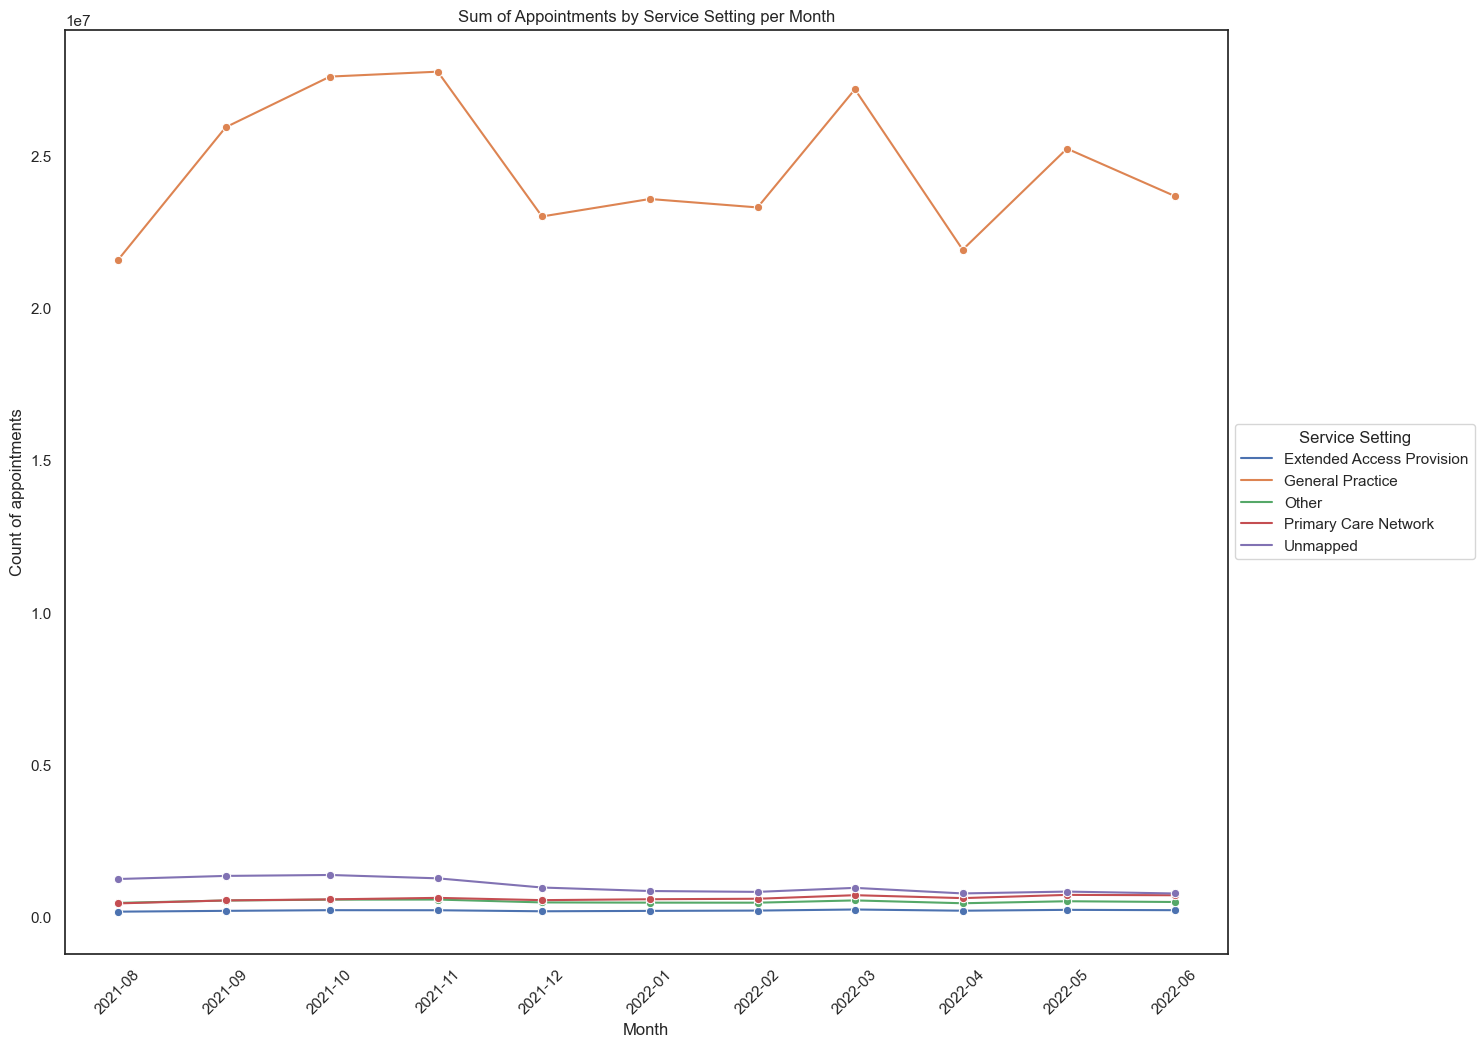

In [73]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.
sns.lineplot(data=nc_sum_of_service_settings_per_month, x='appointment_month', y='count_of_appointments', hue='service_setting', marker='o', linestyle='-')

plt.title('Sum of Appointments by Service Setting per Month')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')
plt.show()

In [75]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'])
print(nc['appointment_date'])

0        2021-08-01
1        2021-08-02
2        2021-08-02
3        2021-08-02
4        2021-08-02
            ...    
817389   2022-06-30
817390   2022-06-30
817391   2022-06-30
817392   2022-06-30
817393   2022-06-30
Name: appointment_date, Length: 817394, dtype: datetime64[ns]


**Context types:**

In [77]:
# Create a separate data set that can be used in future weeks. 
ct_from_national_categories=nc[['appointment_month', 'context_type', 'count_of_appointments']]

# View output.
ct_from_national_categories

,appointment_month,context_type,count_of_appointments
0,2021-08-01,Care Related Encounter,31
1,2021-08-01,Unmapped,1191
2,2021-08-01,Care Related Encounter,3
3,2021-08-01,Care Related Encounter,66
4,2021-08-01,Care Related Encounter,7
...,...,...,...
817389,2022-06-01,Care Related Encounter,12
817390,2022-06-01,Care Related Encounter,4
817391,2022-06-01,Care Related Encounter,92
817392,2022-06-01,Care Related Encounter,4


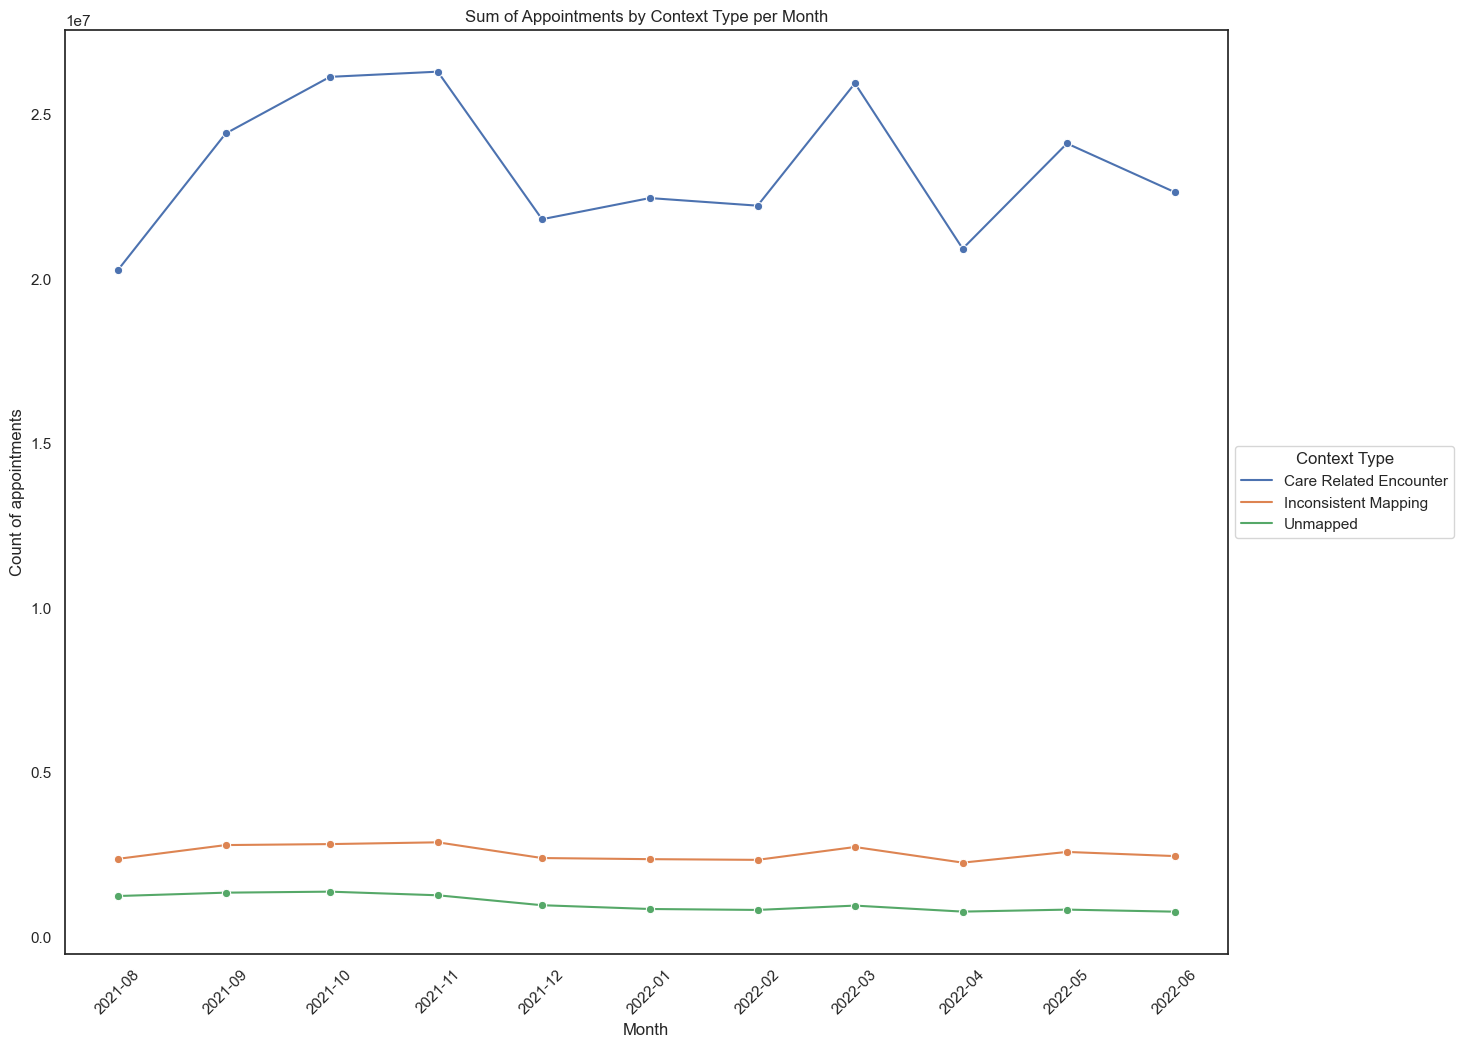

In [79]:
# Plot the appointments over the available date range, and review the context types for months.
nc_context_type_per_month = nc.groupby(['appointment_month', 'context_type'])['count_of_appointments'].sum().reset_index()

# Create a lineplot.
sns.lineplot(data=nc_context_type_per_month, x='appointment_month', y='count_of_appointments', hue='context_type', marker='o', linestyle='-')

plt.title('Sum of Appointments by Context Type per Month')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Context Type', bbox_to_anchor=(1,0.5),loc='center left')
plt.show()

**National categories:**

In [81]:
# Create a separate data set that can be used in future weeks. 
nc_from_national_category=nc[['appointment_month', 'national_category', 'count_of_appointments']]

# View output.
nc_from_national_category

,appointment_month,national_category,count_of_appointments
0,2021-08-01,General Consultation Routine,31
1,2021-08-01,Unmapped,1191
2,2021-08-01,Unplanned Clinical Activity,3
3,2021-08-01,Structured Medication Review,66
4,2021-08-01,Social Prescribing Service,7
...,...,...,...
817389,2022-06-01,Unplanned Clinical Activity,12
817390,2022-06-01,Planned Clinics,4
817391,2022-06-01,Planned Clinical Procedure,92
817392,2022-06-01,General Consultation Routine,4


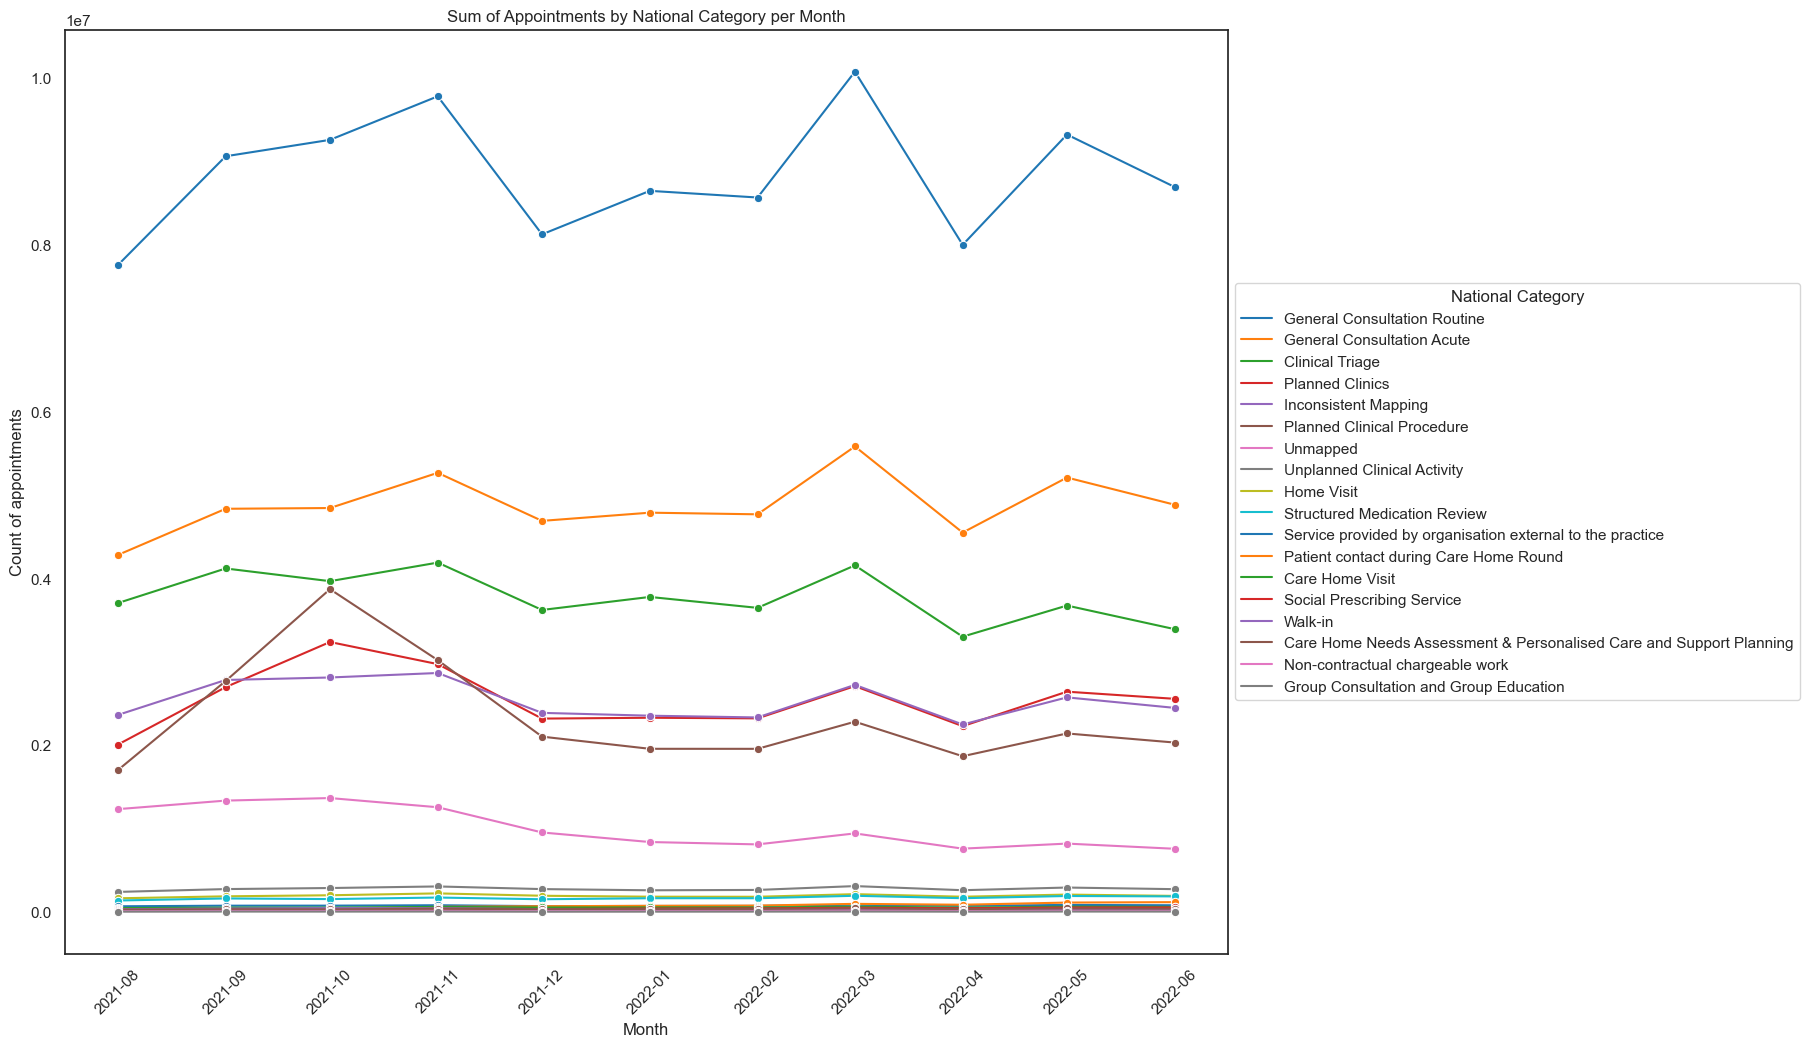

In [87]:
# Plot the appointments over the available date range, and review the national categories for months.
nc_from_national_category = nc.groupby(['appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()

# Calculate total appointments for each category
category_totals = nc_from_national_category.groupby('national_category')['count_of_appointments'].sum()
sorted_categories = category_totals.sort_values(ascending=False).index

# Sort data by `national_category` based on the calculated totals
nc_from_national_category['national_category'] = pd.Categorical(
    nc_from_national_category['national_category'],
    categories=sorted_categories,
    ordered=True)
    
# Create a lineplot.
palette = "tab10" 
sns.lineplot(data=nc_from_national_category, x='appointment_month', y='count_of_appointments', 
             hue='national_category', marker="o", linestyle='-', palette=palette)

plt.title('Sum of Appointments by National Category per Month')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='National Category', bbox_to_anchor=(1,0.5),loc='center left')
plt.show()

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [89]:
# Create a separate data set that can be used in future weeks. 
nc_summer_data = nc[(nc['appointment_month'] >= '2021-06-01') & (nc['appointment_month'] < '2021-09-21')]
nc_summer_service_setting = nc_summer_data.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()
nc_summer_service_setting['appointment_month'] = pd.to_datetime(nc_summer_service_setting['appointment_month'], format='%Y-%m')

# View output.
print(nc_summer_service_setting['appointment_month'].dtype)
nc_summer_service_setting

datetime64[ns]


,appointment_month,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843
5,2021-09-01,Extended Access Provision,187906
6,2021-09-01,General Practice,25940821
7,2021-09-01,Other,527174
8,2021-09-01,Primary Care Network,530485
9,2021-09-01,Unmapped,1336115


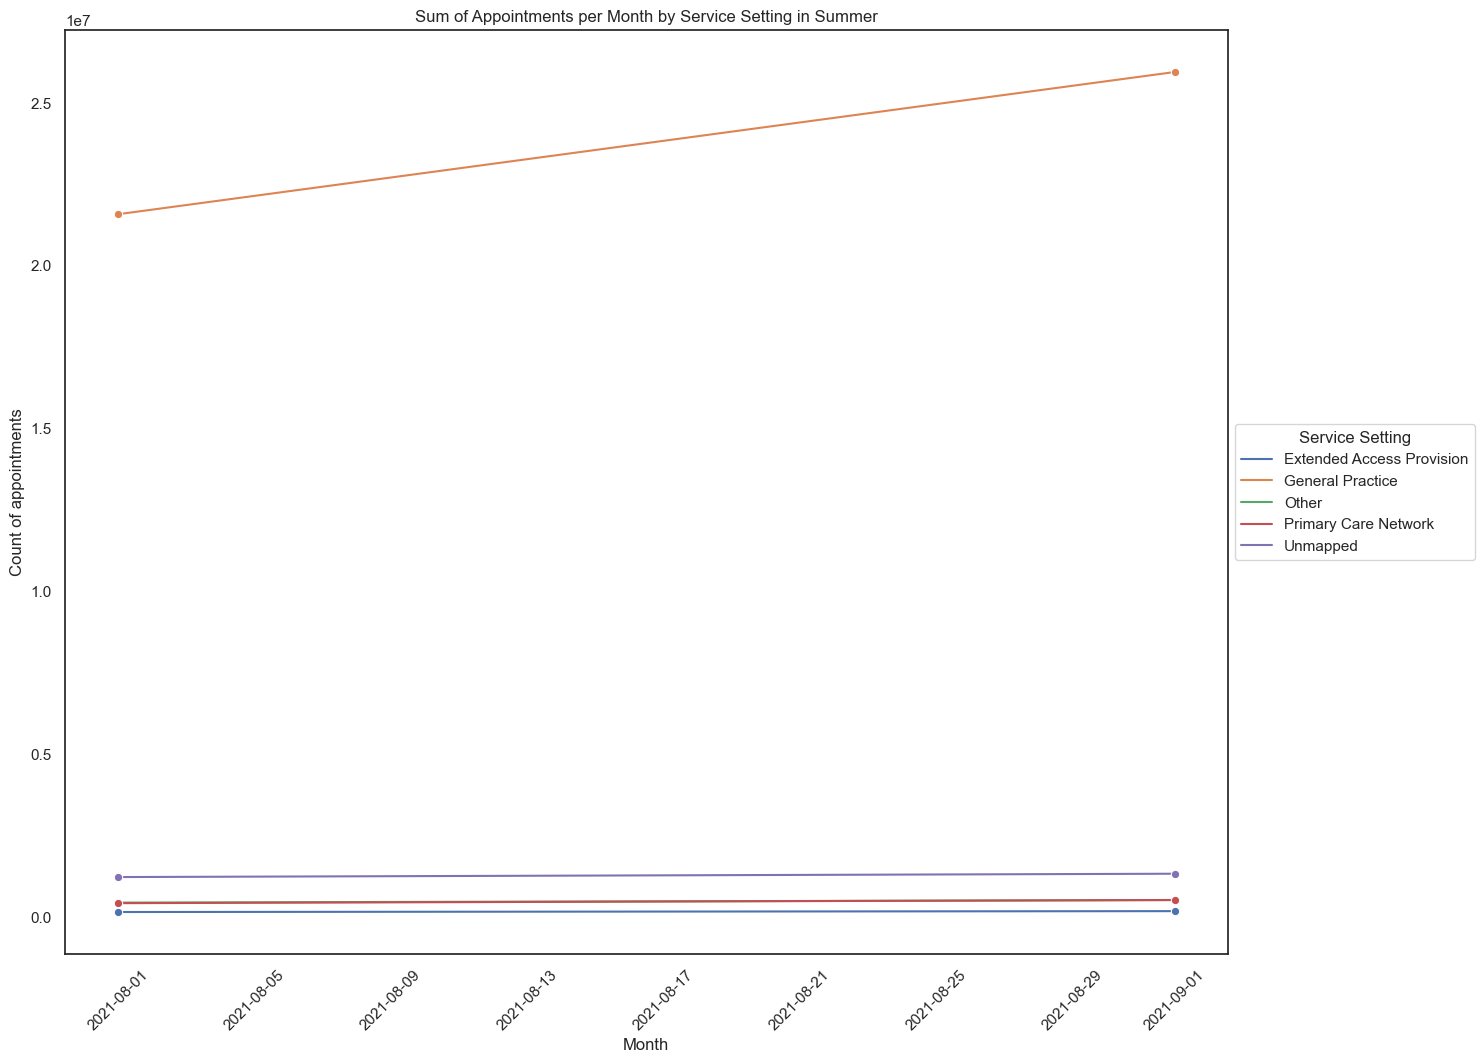

In [91]:
# Look at June to August 2021 in more detail to allow a closer look.

# Create a lineplot.
sns.lineplot(data=nc_summer_service_setting, x='appointment_month', y='count_of_appointments', hue='service_setting', errorbar=None, 
             marker='o', linestyle='-')

plt.title('Sum of Appointments per Month by Service Setting in Summer')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

plt.show()

    appointment_date   service_setting  count_of_appointments
1         2021-08-01  General Practice                   3411
6         2021-08-02  General Practice                1108073
11        2021-08-03  General Practice                1056435
16        2021-08-04  General Practice                 988285
21        2021-08-05  General Practice                 968191
26        2021-08-06  General Practice                 935744
31        2021-08-07  General Practice                  18937
36        2021-08-08  General Practice                   3065
41        2021-08-09  General Practice                1110226
46        2021-08-10  General Practice                1053930
51        2021-08-11  General Practice                 999650
56        2021-08-12  General Practice                 975860
61        2021-08-13  General Practice                 944948
66        2021-08-14  General Practice                  19822
71        2021-08-15  General Practice                   2951
76      

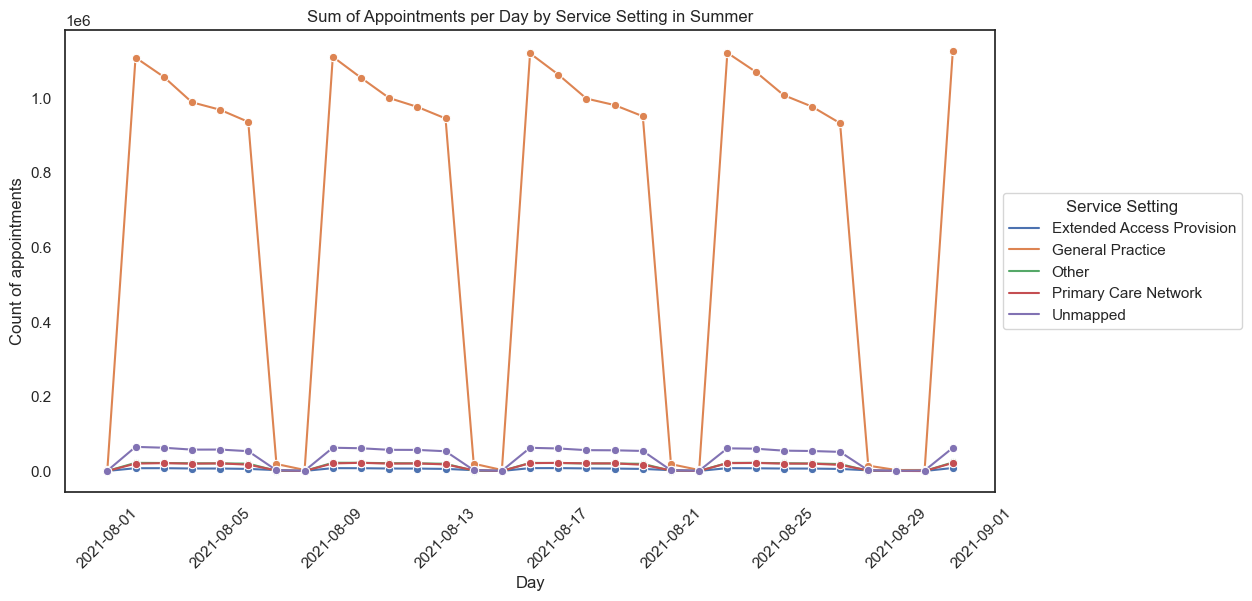

In [93]:
# Ensure 'appointment_date' is in datetime format
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Filter data for Summer (June to August 2021)
nc_summer = nc[(nc['appointment_date'] >= '2021-06-01') & (nc['appointment_date'] <= '2021-08-31')]

# Group by appointment_date and service_setting, and sum the appointments for Summer
nc_summer_agg = nc_summer.groupby(['appointment_date', 'service_setting'])['count_of_appointments'].sum().reset_index()

# Create a line plot for Summer 2021
plt.figure(figsize=(12, 6))
sns.lineplot(data=nc_summer_agg, x='appointment_date', y='count_of_appointments', hue='service_setting', errorbar=None, marker='o', linestyle='-')
plt.title('Sum of Appointments per Day by Service Setting in Summer')
plt.xlabel('Day')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

# Filter the data where service_setting is 'General Practice'
nc_summer_gp = nc_summer_agg[nc_summer_agg['service_setting'] == 'General Practice']

# Display the filtered data
print(nc_summer_gp)

**Autumn (September to November 2021):**

In [95]:
# Look at September to November 2021 in more detail to allow a closer look.
nc_autumn_data = nc[(nc['appointment_month'] >= '2021-09-01') & (nc['appointment_month'] <= '2021-11-30')]
nc_autumn_service_setting = nc_autumn_data.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()
nc_autumn_service_setting['appointment_month'] = pd.to_datetime(nc_autumn_service_setting['appointment_month'], format='%Y-%m')

# View output.
print(nc_autumn_service_setting['appointment_month'].dtype)
nc_autumn_service_setting

datetime64[ns]


,appointment_month,service_setting,count_of_appointments
0,2021-09-01,Extended Access Provision,187906
1,2021-09-01,General Practice,25940821
2,2021-09-01,Other,527174
3,2021-09-01,Primary Care Network,530485
4,2021-09-01,Unmapped,1336115
5,2021-10-01,Extended Access Provision,209539
6,2021-10-01,General Practice,27606171
7,2021-10-01,Other,556487
8,2021-10-01,Primary Care Network,564981
9,2021-10-01,Unmapped,1366656


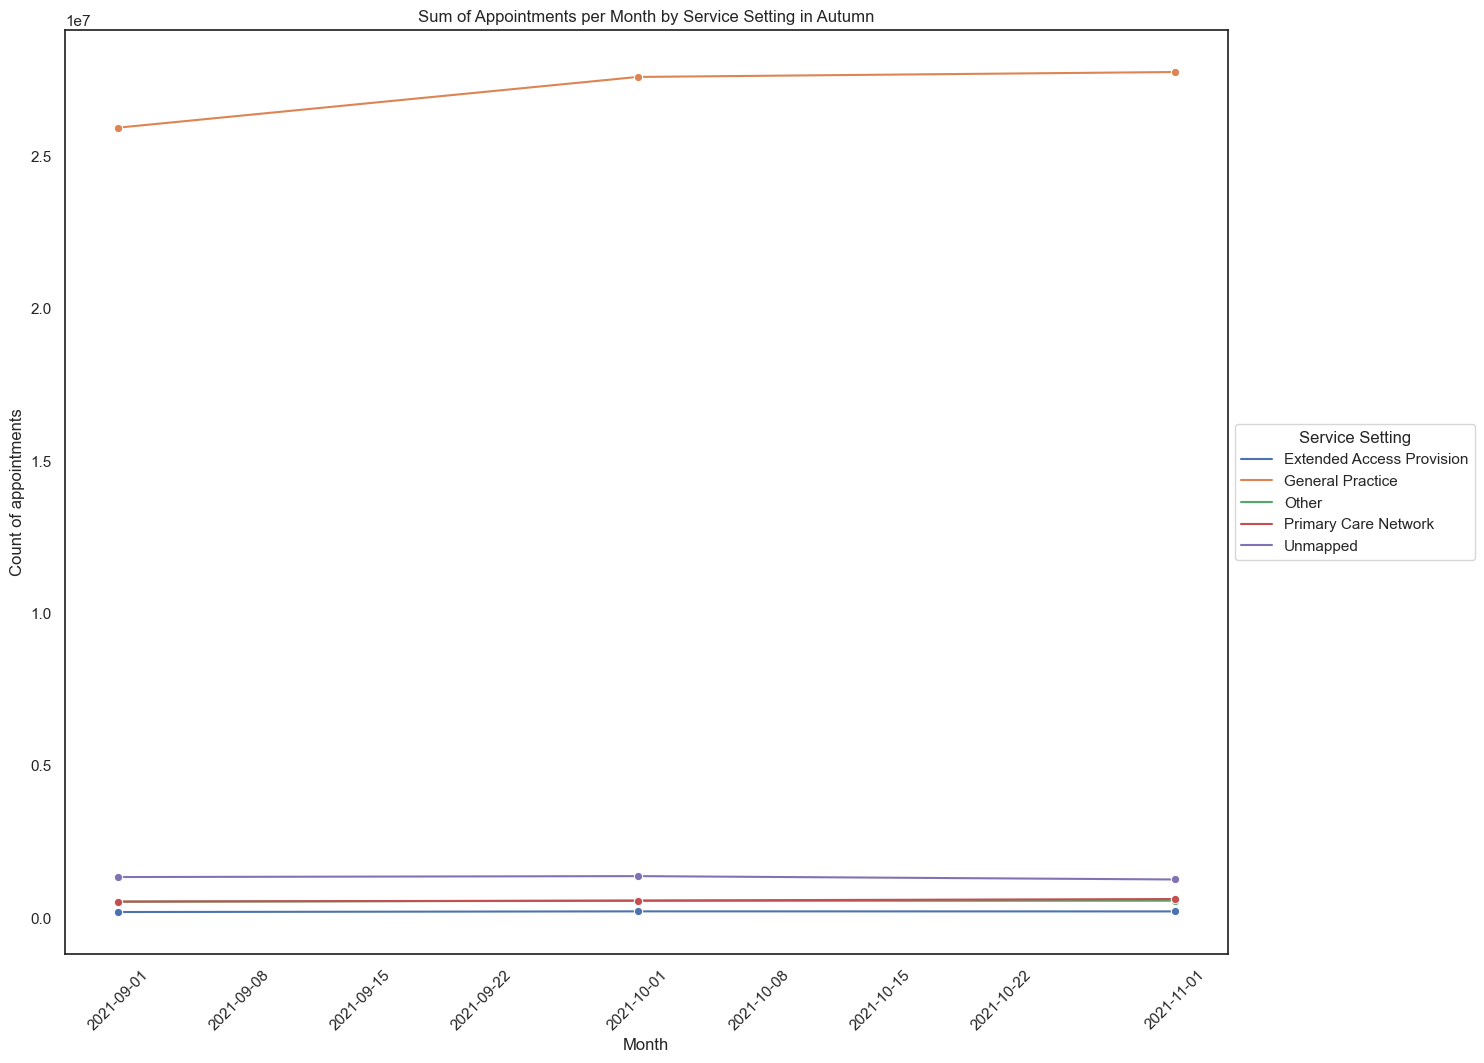

In [97]:
# Create a lineplot.
sns.lineplot(data=nc_autumn_service_setting, x='appointment_month', y='count_of_appointments', hue='service_setting', errorbar=None,
            marker='o', linestyle='-')

plt.title('Sum of Appointments per Month by Service Setting in Autumn')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

plt.show()

    appointment_date   service_setting  count_of_appointments
1         2021-09-01  General Practice                1041879
6         2021-09-02  General Practice                1014376
11        2021-09-03  General Practice                 988674
16        2021-09-04  General Practice                  18543
21        2021-09-05  General Practice                   3017
..               ...               ...                    ...
431       2021-11-26  General Practice                1117571
436       2021-11-27  General Practice                 117930
441       2021-11-28  General Practice                   9089
446       2021-11-29  General Practice                1302990
451       2021-11-30  General Practice                1254637

[91 rows x 3 columns]


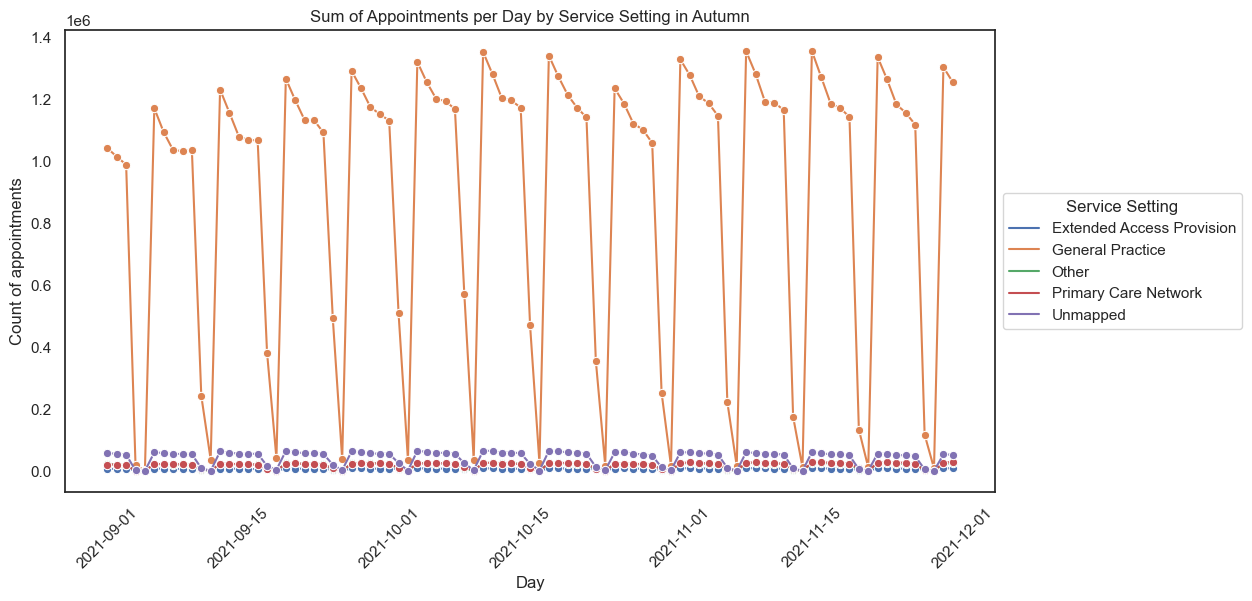

In [99]:
# Ensure 'appointment_date' is in datetime format
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Filter data for Autumn (September to November 2021)
nc_autumn_data = nc[(nc['appointment_month'] >= '2021-09-01') & (nc['appointment_month'] <= '2021-11-30')]

# Group by appointment_date and service_setting, and sum the appointments for Autumn
nc_autumn_agg = nc_autumn_data.groupby(['appointment_date', 'service_setting'])['count_of_appointments'].sum().reset_index()

# Create a line plot for Autumn 2021
plt.figure(figsize=(12, 6))
sns.lineplot(data=nc_autumn_agg, x='appointment_date', y='count_of_appointments', hue='service_setting', errorbar=None, marker='o', linestyle='-')
plt.title('Sum of Appointments per Day by Service Setting in Autumn')
plt.xlabel('Day')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

# Filter the data where service_setting is 'General Practice'
nc_autumn_gp = nc_autumn_agg[nc_autumn_agg['service_setting'] == 'General Practice']

# Display the filtered data
print(nc_autumn_gp)

**Winter (December to February 2022):**

In [101]:
# Look at December to February 2022 in more detail to allow a closer look.
nc_winter_data = nc[(nc['appointment_month'] >= '2021-12-01') & (nc['appointment_month'] < '2022-03-01')]
nc_winter_service_setting = nc_winter_data.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()
nc_winter_service_setting['appointment_month'] = pd.to_datetime(nc_winter_service_setting['appointment_month'], format='%Y-%m')

# View output.
print(nc_winter_service_setting['appointment_month'].dtype)
nc_winter_service_setting

datetime64[ns]


,appointment_month,service_setting,count_of_appointments
0,2021-12-01,Extended Access Provision,173504
1,2021-12-01,General Practice,23008818
2,2021-12-01,Other,464718
3,2021-12-01,Primary Care Network,539479
4,2021-12-01,Unmapped,954257
5,2022-01-01,Extended Access Provision,186375
6,2022-01-01,General Practice,23583053
7,2022-01-01,Other,457440
8,2022-01-01,Primary Care Network,569044
9,2022-01-01,Unmapped,839562


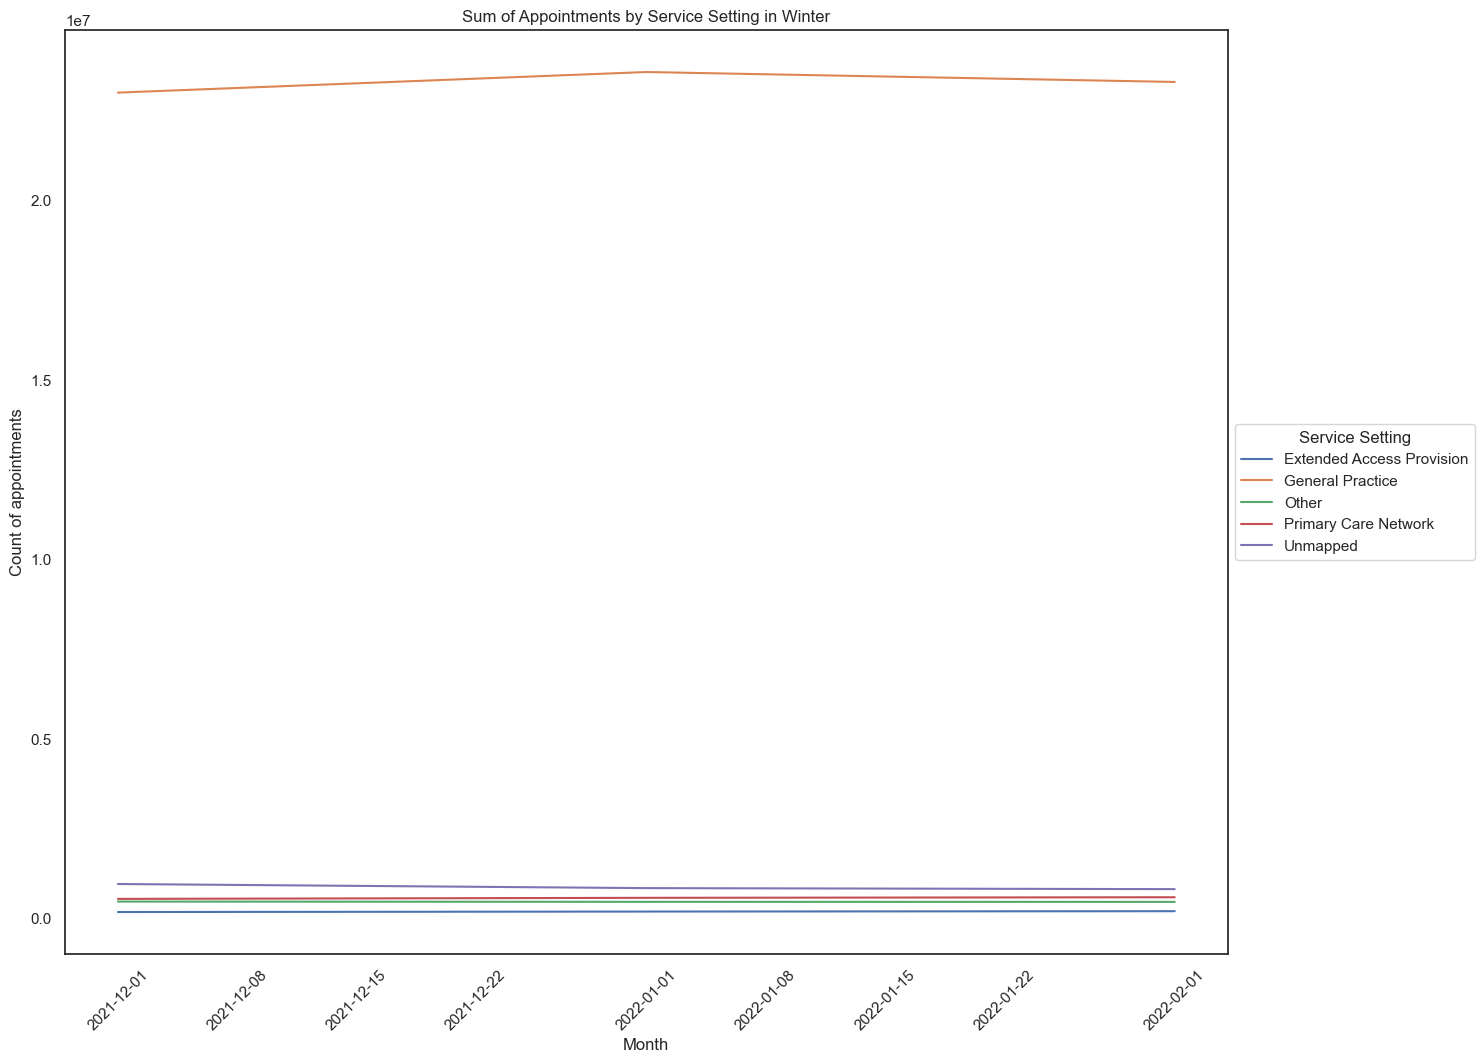

In [103]:
# Create a lineplot.
sns.lineplot(data=nc_winter_service_setting, x='appointment_month', y='count_of_appointments', hue='service_setting', errorbar=None)

plt.title('Sum of Appointments by Service Setting in Winter')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

plt.show()

    appointment_date   service_setting  count_of_appointments
1         2021-12-01  General Practice                1162676
6         2021-12-02  General Practice                1149039
11        2021-12-03  General Practice                1110060
16        2021-12-04  General Practice                  82337
21        2021-12-05  General Practice                  10084
..               ...               ...                    ...
426       2022-02-24  General Practice                1085943
431       2022-02-25  General Practice                1056161
436       2022-02-26  General Practice                  26519
441       2022-02-27  General Practice                   4514
446       2022-02-28  General Practice                1301433

[90 rows x 3 columns]


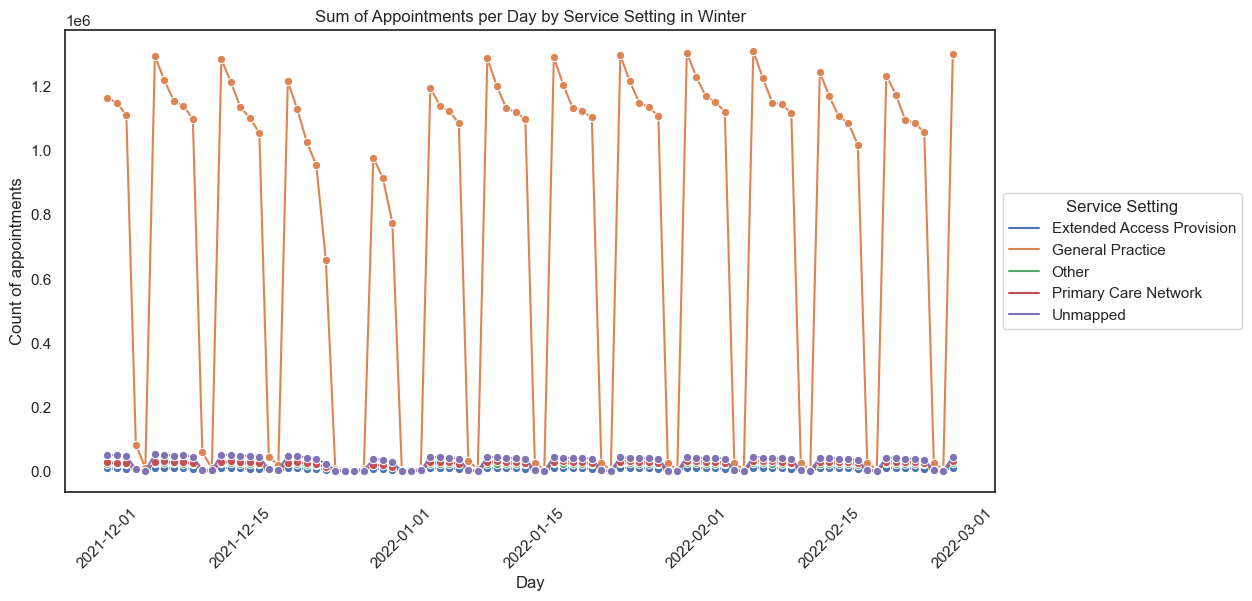

In [105]:
# Ensure 'appointment_date' is in datetime format
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Filter data for Winter (December 2021 to March 2022)
nc_winter_data = nc_winter_data = nc[(nc['appointment_month'] >= '2021-12-01') & (nc['appointment_month'] < '2022-03-01')]

# Group by appointment_date and service_setting, and sum the appointments for Winter
nc_winter_agg = nc_winter_data.groupby(['appointment_date', 'service_setting'])['count_of_appointments'].sum().reset_index()

# Create a line plot for Winter 2021 - 2022
plt.figure(figsize=(12, 6))
sns.lineplot(data=nc_winter_agg, x='appointment_date', y='count_of_appointments', hue='service_setting', errorbar=None, marker='o', linestyle='-')
plt.title('Sum of Appointments per Day by Service Setting in Winter')
plt.xlabel('Day')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

# Filter the data where service_setting is 'General Practice'
nc_winter_gp = nc_winter_agg[nc_winter_agg['service_setting'] == 'General Practice']

# Display the filtered data
print(nc_winter_gp)

**Spring (March to May 2022):**

In [107]:
# Look at March to May 2022 in more detail to allow a closer look.
nc_spring_data = nc[(nc['appointment_month'] >= '2022-03-01') & (nc['appointment_month'] < '2022-05-31')]
nc_spring_service_setting = nc_spring_data.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()
nc_spring_service_setting['appointment_month'] = pd.to_datetime(nc_spring_service_setting['appointment_month'], format='%Y-%m')

# View output.
print(nc_spring_service_setting['appointment_month'].dtype)
nc_spring_service_setting

datetime64[ns]


,appointment_month,service_setting,count_of_appointments
0,2022-03-01,Extended Access Provision,231905
1,2022-03-01,General Practice,27187368
2,2022-03-01,Other,530677
3,2022-03-01,Primary Care Network,702176
4,2022-03-01,Unmapped,942912
5,2022-04-01,Extended Access Provision,192284
6,2022-04-01,General Practice,21916791
7,2022-04-01,Other,437402
8,2022-04-01,Primary Care Network,606270
9,2022-04-01,Unmapped,760313


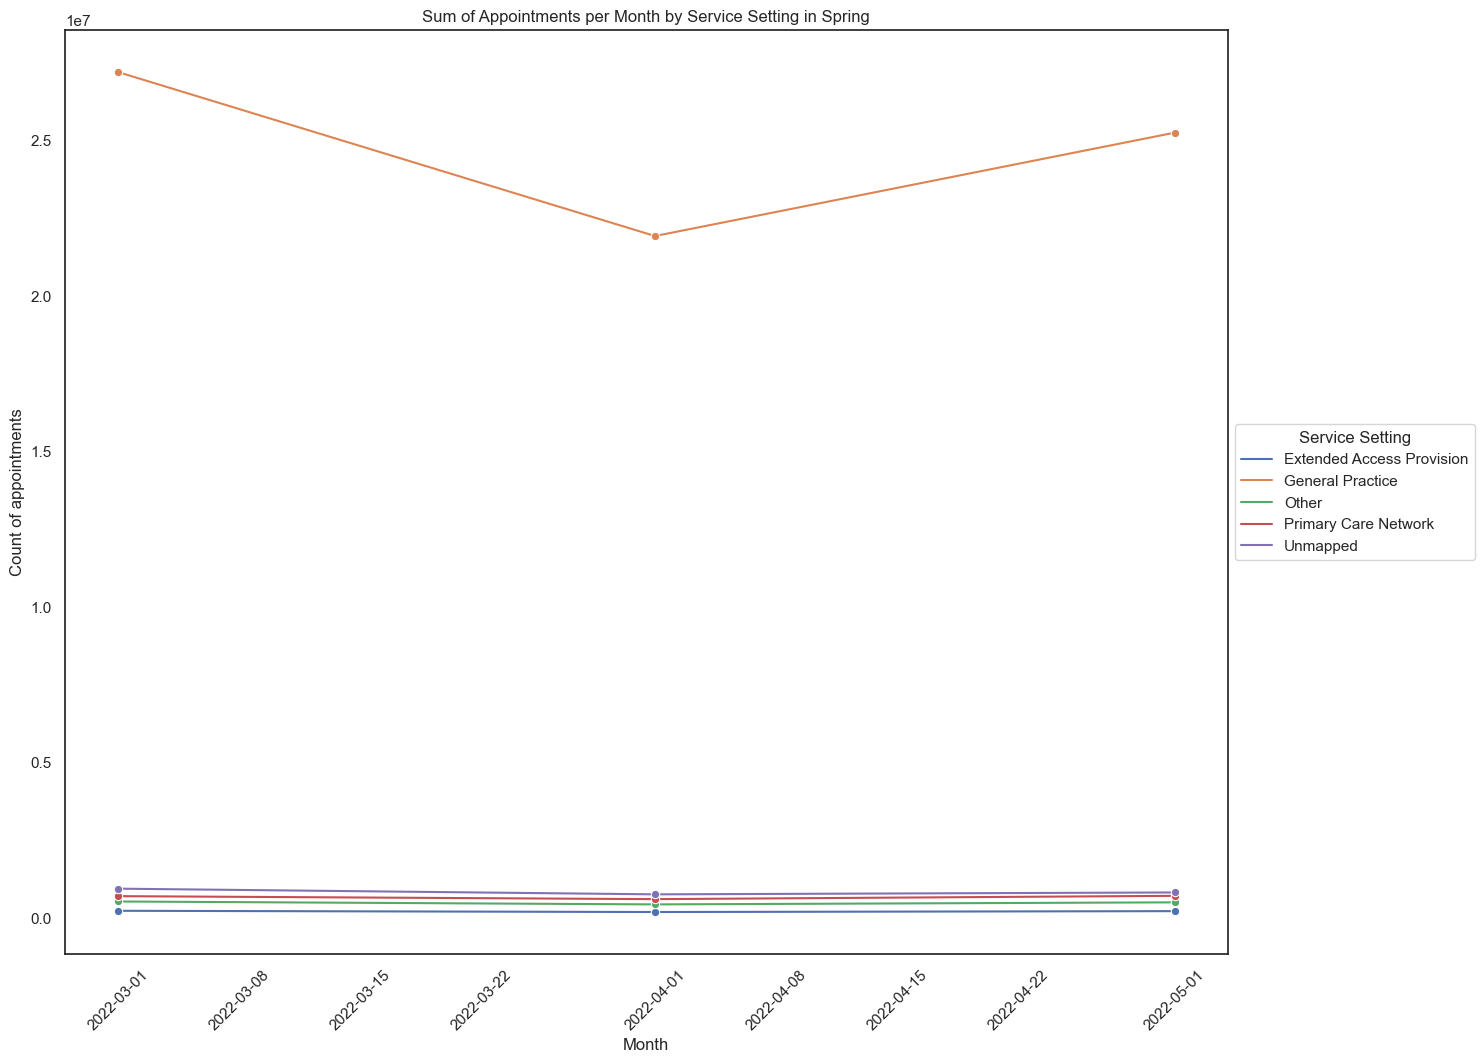

In [111]:
# Create a lineplot.
sns.lineplot(data=nc_spring_service_setting, x='appointment_month', y='count_of_appointments', hue='service_setting', errorbar=None,
            marker='o', linestyle='-')

plt.title('Sum of Appointments per Month by Service Setting in Spring')
plt.xlabel('Month')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability

plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')
plt.show()

    appointment_date   service_setting  count_of_appointments
1         2022-03-01  General Practice                1229045
6         2022-03-02  General Practice                1164221
11        2022-03-03  General Practice                1145324
16        2022-03-04  General Practice                1121304
21        2022-03-05  General Practice                  28086
..               ...               ...                    ...
436       2022-05-27  General Practice                1104330
441       2022-05-28  General Practice                  24571
446       2022-05-29  General Practice                   3969
451       2022-05-30  General Practice                1208960
456       2022-05-31  General Practice                1154859

[92 rows x 3 columns]


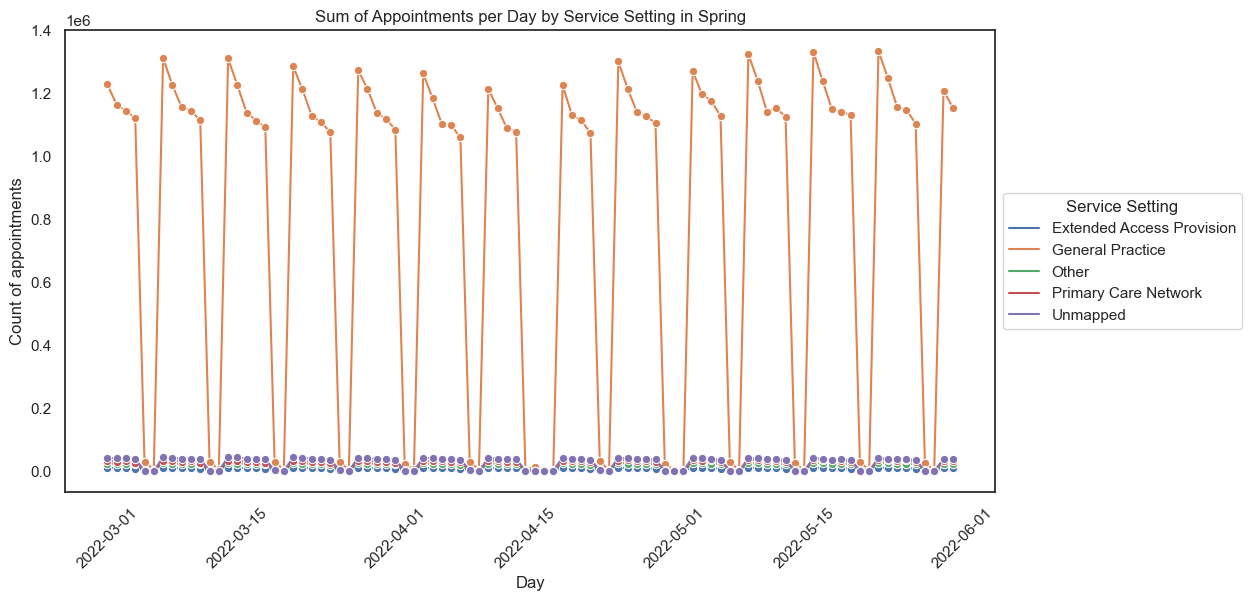

In [113]:
# Ensure 'appointment_date' is in datetime format
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], errors='coerce')

# Filter data for Spring (March to June)
nc_spring_data = nc[(nc['appointment_month'] >= '2022-03-01') & (nc['appointment_month'] < '2022-05-31')]

# Group by appointment_date and service_setting, and sum the appointments for Spring
nc_spring_agg = nc_spring_data.groupby(['appointment_date', 'service_setting'])['count_of_appointments'].sum().reset_index()

# Create a line plot for Spring
plt.figure(figsize=(12, 6))
sns.lineplot(data=nc_spring_agg, x='appointment_date', y='count_of_appointments', hue='service_setting', errorbar=None, marker='o', linestyle='-')
plt.title('Sum of Appointments per Day by Service Setting in Spring')
plt.xlabel('Day')
plt.ylabel('Count of appointments')
plt.xticks(rotation=45)  # Rotate X axis labels for better readability
plt.legend(title='Service Setting', bbox_to_anchor=(1,0.5),loc='center left')

# Filter the data where service_setting is 'General Practice'
nc_spring_gp = nc_spring_agg[nc_spring_agg['service_setting'] == 'General Practice']

# Display the filtered data
print(nc_spring_gp)

# 

# Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [115]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [117]:
# Load the data set.
tweets_df = pd.read_csv((r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator'
                 r'\Course 2\Assigment\LSE_DA201_Assignment_files- UPDATED\LSE_DA201_Assignment_files\tweets.csv'))

# View the DataFrame.
tweets_df.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [139]:
# Explore the metadata.
print('The descriptive statistic for the tweets dataframe is:')
print(tweets_df.describe())  # Shows descriptive statistics for numerical columns

print('\n')  # Empty line for better readability

print('The info on the tweets dataframe are:')
print(tweets_df.info())

The descriptive statistic for the tweets dataframe is:
           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std    2.427553e+13            29.784675               2.04470
min    1.567574e+18             0.000000               0.00000
25%    1.567590e+18             0.000000               0.00000
50%    1.567611e+18             1.000000               0.00000
75%    1.567633e+18             3.000000               0.00000
max    1.567655e+18           303.000000              42.00000


The info on the tweets dataframe are:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities

In [141]:
# Explore the data set.
# Explore tweet_retweet_count with value_counts()
print("Tweet Retweet Count Distribution:")
print(tweets_df['tweet_retweet_count'].value_counts())

print('\n')  # Empty line for better readability

# Explore tweet_favorite_count with value_counts()
print("Tweet Favorite Count Distribution:")
print(tweets_df['tweet_favorite_count'].value_counts())


Tweet Retweet Count Distribution:
tweet_retweet_count
0      526
1      215
2      114
3       70
5       35
4       27
7       18
12      16
8       15
73      14
9       13
6       12
208     12
35      10
37       6
11       6
10       5
53       5
44       4
150      4
63       4
76       3
85       3
41       3
62       3
207      3
68       3
78       2
23       2
24       2
72       2
16       2
13       1
49       1
48       1
15       1
107      1
14       1
79       1
20       1
39       1
19       1
303      1
57       1
40       1
54       1
169      1
Name: count, dtype: int64


Tweet Favorite Count Distribution:
tweet_favorite_count
0     1027
1       91
2       16
3       13
4        7
5        5
6        2
17       1
12       1
10       1
8        1
13       1
11       1
7        1
20       1
28       1
14       1
18       1
9        1
42       1
Name: count, dtype: int64


In [90]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Explain your answer.

No, looking only at the retweeted and favourite tweet messages wouldn't be useful. Such info should be compared and crossed with other info. For eaxample the most used words in the retweted and favoutite tweets. What are they about? Promoting services, insurances? This could give hints to the marketing team, for example. 

In [143]:
# Create a new DataFrame containing only the text.
tweets_text = tweets_df.select_dtypes(include=['object'])

# View the DataFrame.
tweets_text

,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_lang
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",en
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",en
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",en
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",en
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",en
...,...,...,...,...,...
1169,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…,"{'hashtags': [{'text': 'Innovation', 'indices': [29, 40]}, {'text': 'precisionFabrication', 'indices': [50, 71]}, {'text': 'Microfluidic', 'indices': [92, 105]}], 'symbols': [], 'user_mentions': [...","#Innovation, #precisionFabrication, #Microfluidic","{'iso_language_code': 'en', 'result_type': 'recent'}",en
1170,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie...","{'hashtags': [{'text': 'SKPoli', 'indices': [232, 239]}, {'text': 'healthcare', 'indices': [240, 251]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/33f7Dz5FrU', 'expanded_u...","#SKPoli, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",en
1171,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp...","{'hashtags': [{'text': 'webinar', 'indices': [149, 157]}, {'text': 'ESG', 'indices': [209, 213]}, {'text': 'healthcare', 'indices': [235, 246]}], 'symbols': [], 'user_mentions': [{'screen_name': '...","#webinar, #ESG, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",en
1172,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYym

In [145]:
# Loop through the messages, and create a list of values containing the # symbol.

# Create an empty list to store values containing the # symbol
hashtags_list = []

# Loop through the messages
for tweet in tweets_text['tweet_full_text'].values:
    # Split each message into words
    for word in tweet.split():
        # Check for words containing #
        if '#' in word:
            # Change to lowercase and append to the list
            hashtags_list.append(word.lower())

# Print the resulting list of hashtags
print(hashtags_list)

# Convert the list to a set to get unique hashtags
unique_hashtags = set(hashtags_list)

# Count the number of unique hashtags
unique_hashtags_count = len(unique_hashtags)

# Print the number of unique hashtags
print(f"Number of unique hashtags: {unique_hashtags_count}")

['#healthcare', '#premisehealth', '#hiring', '#healthcare', '🚨#new:🚨', '#blogs', '#digitaltransformation', '#cybersecurity', '#accounting', '#finance', '#healthcare', '#firstcoastcna', '#cnaexam', '#cnaexampreparation', '#jacksonville', '#cnatraining', '#nurse', '#nursing', '#nurselife', '#nursepractitioner', '#nurseproblems', '#nursingschool', '#healthcare', '🚨#new:🚨', '#disparities.', '#healthcare', '#alert', '#insurance', '#data', '#healthcare', '#healthcare', '#healthcare', '#healthcare', '#hcldr', '#premisehealth', '#hiring', '#premisehealth', '#hiring', '#healthcare', '#qualitypatientcare', '#jobs', '#job', '#ascp2022', '#ascp100.', '#healthcare', '#healthsecretary', '#healthcare', '#ai,', '#sdoh,', '#healthcare', '#tropicana', '#real', '#juice', '#healthcare', '#watch', '#worms', '#fruits', '#healthtips', '#tips', '#healthcare', '#thewoodlands,', '#healthcare', '#chicago,', '#healthcare', '#telehealth', '#healthcare', '#virtualcare', '#mediqueststaffing', '#hospital', '#shift', 

In [147]:
# Display the first 30 records.
hashtags_list[:30]

['#healthcare',
 '#premisehealth',
 '#hiring',
 '#healthcare',
 '🚨#new:🚨',
 '#blogs',
 '#digitaltransformation',
 '#cybersecurity',
 '#accounting',
 '#finance',
 '#healthcare',
 '#firstcoastcna',
 '#cnaexam',
 '#cnaexampreparation',
 '#jacksonville',
 '#cnatraining',
 '#nurse',
 '#nursing',
 '#nurselife',
 '#nursepractitioner',
 '#nurseproblems',
 '#nursingschool',
 '#healthcare',
 '🚨#new:🚨',
 '#disparities.',
 '#healthcare',
 '#alert',
 '#insurance',
 '#data',
 '#healthcare']

In [149]:
# Convert the series to a DataFrame in preparation for visualisation.
hashtags_series = pd.Series(hashtags_list)  

# Convert the Series to a DataFrame
hashtags_df = hashtags_series.to_frame(name='#')

# Rename the columns.
hashtags_df.rename(columns={'#': 'Hashtags'}, inplace=True)

In [151]:
# Fix the count datatype.

# Get the count of each unique hashtag
hashtag_counts = hashtags_df['Hashtags'].value_counts().reset_index()

# Rename the columns appropriately
hashtag_counts.columns = ['Hashtag', 'Count']

# View the result.
print(hashtag_counts)

                 Hashtag  Count
0            #healthcare    785
1                #health     84
2                    #ai     45
3              #medicine     42
4                   #job     38
...                  ...    ...
1626  #fitnessmotivation      1
1627             #london      1
1628              #dance      1
1629      #futureofwork.      1
1630              #csjmu      1

[1631 rows x 2 columns]


In [153]:
# Display records where the count is larger than 10.
hastags_counts_more_that_10 = hashtag_counts[hashtag_counts['Count'] > 10]

hastags_counts_more_that_10

,Hashtag,Count
0,#healthcare,785
1,#health,84
2,#ai,45
3,#medicine,42
4,#job,38
5,#medical,35
6,#strategy,30
7,#digitalhealth,30
8,#pharmaceutical,28
9,#medtwitter,27


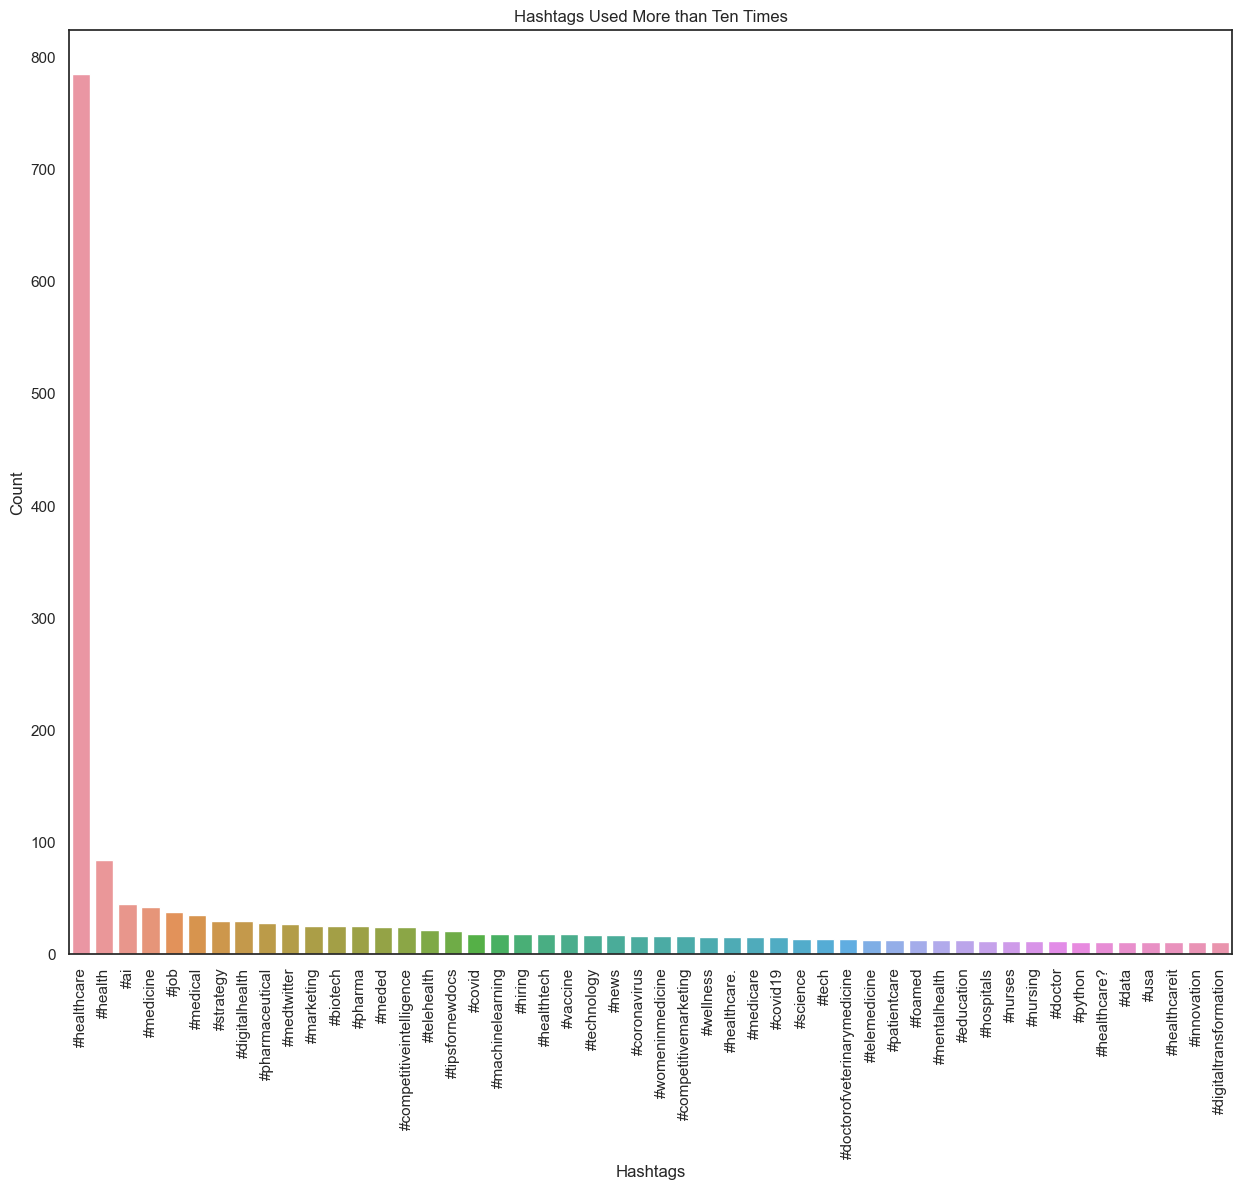

In [155]:
# Create a Seaborn barplot indicating records with a count >10 records.
sns.barplot(x='Hashtag', y='Count', data=hastags_counts_more_that_10)

# Add title and labels
plt.title('Hashtags Used More than Ten Times')
plt.xlabel('Hashtags')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate X axis labels for better readability

# Show the plot
plt.show()

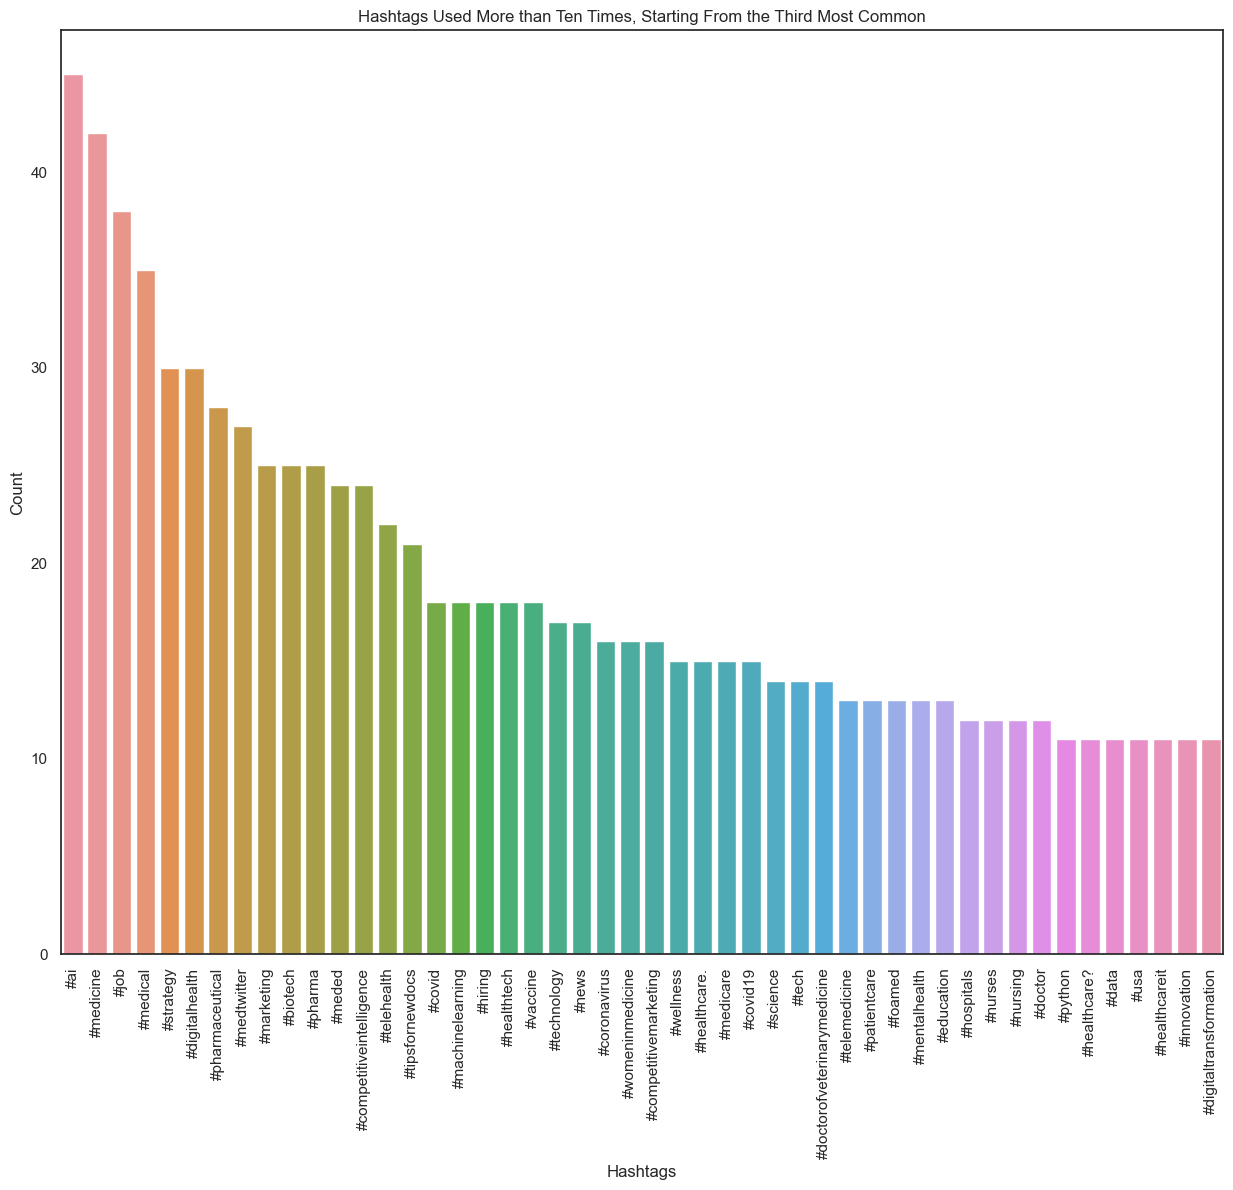

In [157]:
# Create the plot.

# Create a dataframe with the most common hashtags aftetr th first two.
Most_common_hastags_after_first_two = hastags_counts_more_that_10.iloc[2:] 

# Display the result
Most_common_hastags_after_first_two

# Create a Seaborn barplot indicating the most common hashtags aftetr th first two.
sns.barplot(x='Hashtag', y='Count', data=Most_common_hastags_after_first_two)

# Add title and labels
plt.title('Hashtags Used More than Ten Times, Starting From the Third Most Common')
plt.xlabel('Hashtags')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate X axis labels for better readability

# Show the plot
plt.show()

### How your team can utilise tweets to provide feedback to the stakeholders  

Our team could use tweets from NHS to perform statistical analysis on the most used hashtags. We could rank them, and divide them as suggestion, complains, or feedbacks. In this way, we will give a good base for further decisions to the management. 

### Whether the tweets add value to the overall project  
  
Definitely tweets can be useful, if analysis if perfomed on them. Hastag and word frequency, related to a particular period of time (after a new law, or after a major change or event, for example).

### How the NHS can utilise tweets

There are multiple ways NHS could use Twitter. For example
- Use it to share the news about NHS, such as new policies, how laws are followed, new research achievements, and so on,
- Customer care, by answering tweets and comments,
- Sending tweets on a particular topic, collect the replies, and analyze them. 

### Any suggestions regarding data collection or analysis to improve future efforts.  

NHS could collect tweets based on keywords and hashtags, chosen by the topic NHS wants to investigate. Then statistical analysis could be performed, in order to sugest where to invest funds and what to improve. 

# Assignment activity 6

### Make recommendations to the NHS. 

In [159]:
# Prepare your workstation.
# Load the appointments_regional.csv file.
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator'
                 r'\Course 2\Assigment\LSE_DA201_Assignment_files- UPDATED\LSE_DA201_Assignment_files\appointments_regional.csv')

# View the DataFrame.
print(ar.shape)
print('\n')
print(ar.columns)
print('\n')
ar.head()

(596821, 7)


Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')




,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [161]:
# Print the min and max dates.

# Convert the 'appointment_month' column to datetime if it isn't already
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# Print the minimum and maximum dates
min_date = ar['appointment_month'].min()
max_date = ar['appointment_month'].max()

print("Minimum date:", min_date)
print("Maximum date:", max_date)

Minimum date: 2020-01-01 00:00:00
Maximum date: 2022-06-01 00:00:00


In [163]:
# Filter the data set to only look at data from 2021-08 onwards.

# Convert the 'appointment_month' to datetime format
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], format='%Y-%m-%d')

# Filter the data for appointments from 2021-08 onwards
filtered_data = ar[ar['appointment_month'] >= '2021-08']

# Check the filtered data
print(filtered_data.shape)
print('\n')
print(filtered_data.columns)
print('\n')
filtered_data

(223418, 7)


Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')




,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08-01,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,4961
...,...,...,...,...,...,...,...
596816,E54000050,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06-01,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06-01,Unknown,Unknown,Unknown,More than 28 Days,17


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [165]:
# Create an aggregated data set to review the different features.
ar_agg = filtered_data.groupby(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type', 'appointment_mode',
                                         'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_agg

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000008,2021-08-01,Attended,GP,Face-to-Face,1 Day,28360
1,E54000008,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,6345
2,E54000008,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,45744
3,E54000008,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,3061
4,E54000008,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,14940
...,...,...,...,...,...,...,...
108973,E54000062,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,58
108974,E54000062,2022-06-01,Unknown,Unknown,Unknown,22 to 28 Days,20
108975,E54000062,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,67
108976,E54000062,2022-06-01,Unknown,Unknown,Unknown,More than 28 Days,13


In [167]:
# Determine the total number of appointments per month.
ar_df = ar_agg.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_df['utilisation_%'] = (ar_df['count_of_appointments'] / 30) / 1200000 * 100  # Calculate as percentage
ar_df['utilisation_%'] = ar_df['utilisation_%'].round(1)

# View the DataFrame.
ar_df

,appointment_month,count_of_appointments,utilisation_%
0,2021-08-01,23852171,66.3
1,2021-09-01,28522501,79.2
2,2021-10-01,30303834,84.2
3,2021-11-01,30405070,84.5
4,2021-12-01,25140776,69.8
5,2022-01-01,25635474,71.2
6,2022-02-01,25355260,70.4
7,2022-03-01,29595038,82.2
8,2022-04-01,23913060,66.4
9,2022-05-01,27495508,76.4


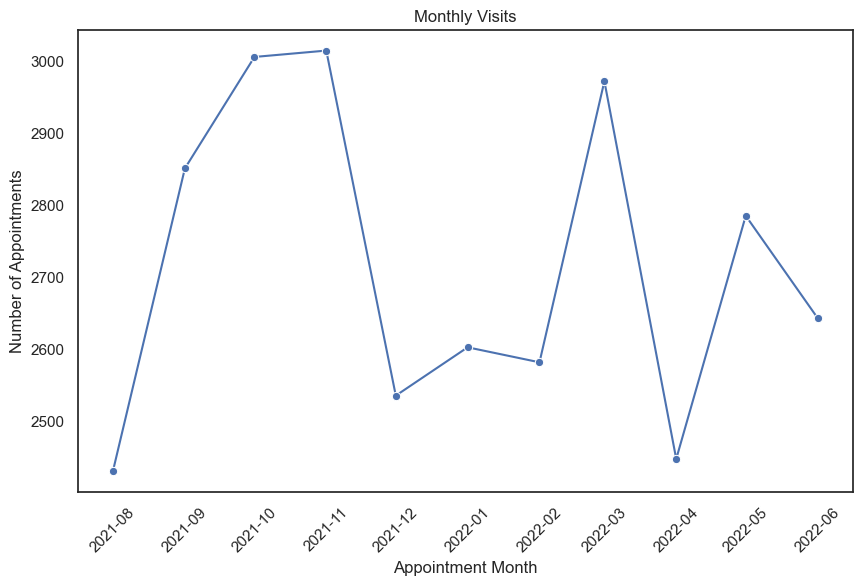

In [169]:
# Plot sum of count of monthly visits.
plt.figure(figsize=(10, 6))
sns.lineplot(data=ar_agg, x='appointment_month', y='count_of_appointments', marker='o', color='b', errorbar=None)
plt.xticks(rotation=45)
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Visits')
plt.show()

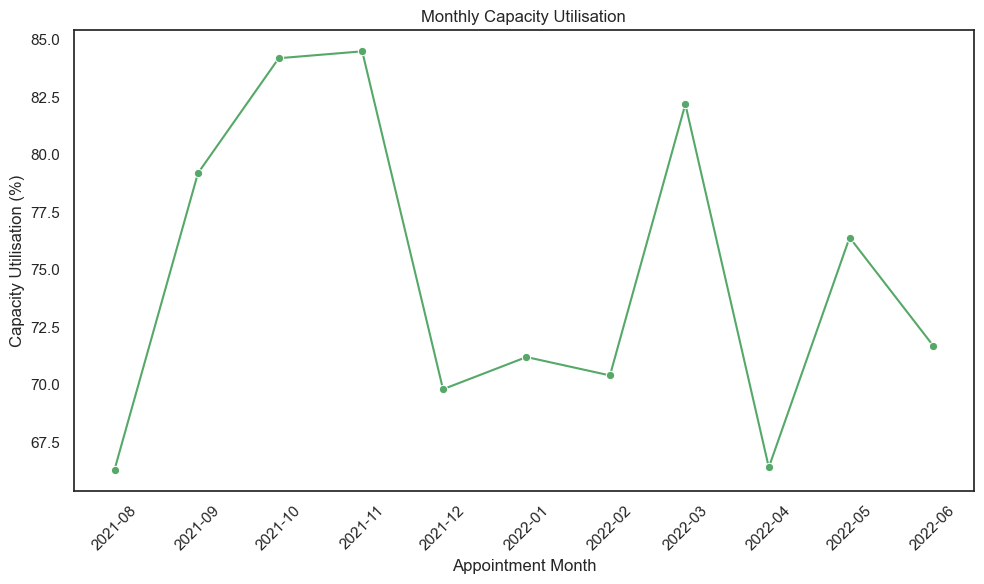

In [171]:
# Plot monthly capacity utilisation.
plt.figure(figsize=(10, 6))
sns.lineplot(data=ar_df, x='appointment_month', y='utilisation_%', marker='o', color='g')
plt.xticks(rotation=45)
plt.xlabel('Appointment Month')
plt.ylabel('Capacity Utilisation (%)')
plt.title('Monthly Capacity Utilisation')
plt.tight_layout()
plt.show()


**Question 2:** How do the healthcare professional types differ over time?

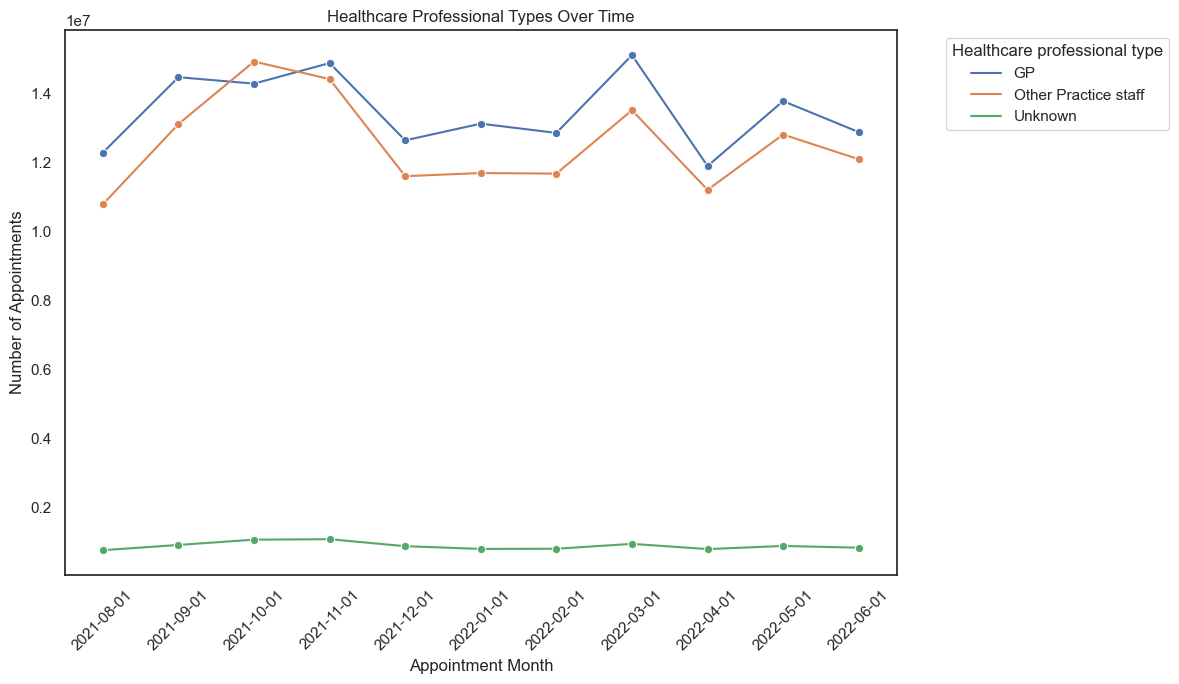

In [173]:
# Create a line plot to answer the question.
hcp_trend = ar_agg.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()

# Convert appointment_month to string for better visualization on x-axis
hcp_trend['appointment_month'] = hcp_trend['appointment_month'].astype(str)

# Line plot for different healthcare professional types over time
plt.figure(figsize=(12, 7))
sns.lineplot(data=hcp_trend, x='appointment_month', y='count_of_appointments', hue='hcp_type', marker='o')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding labels and title
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')
plt.title('Healthcare Professional Types Over Time')

# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Healthcare professional type')

# Display the plot
plt.tight_layout()
plt.show()

**Question 3:** Are there significant changes in whether or not visits are attended?

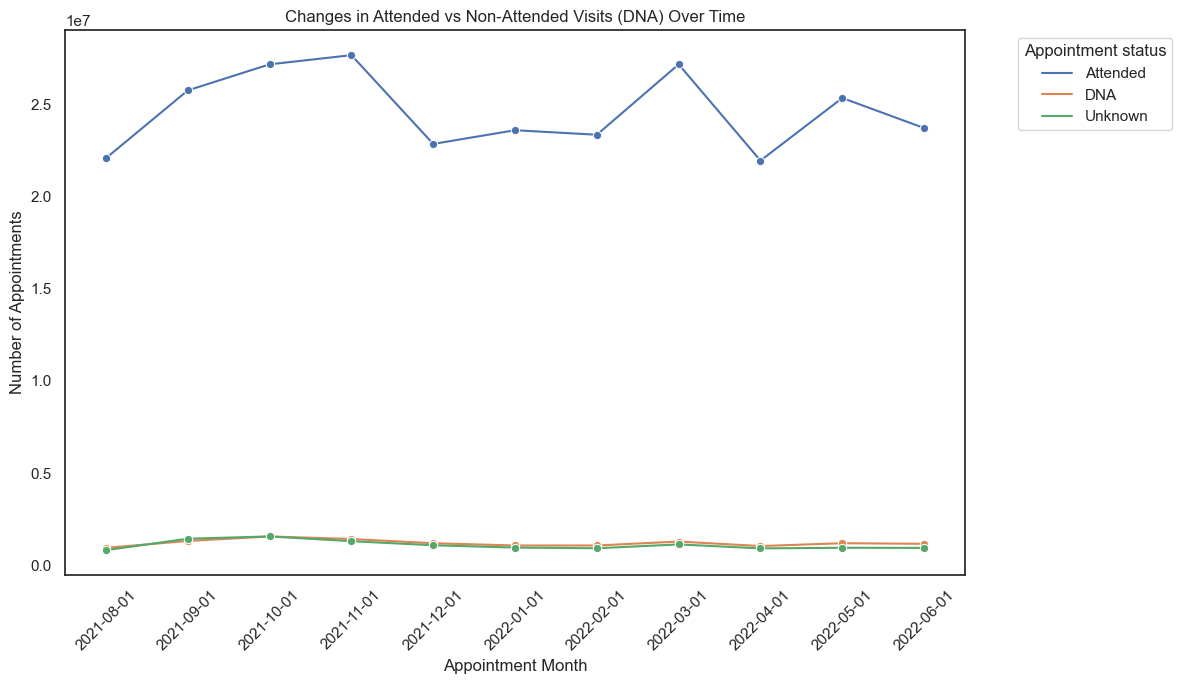

In [175]:
# Create a line plot to answer the question.

# Grouping by appointment_month and appointment_status, summing count_of_appointments
status_trend = ar_agg.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# Convert appointment_month to string for better visualization on x-axis
status_trend['appointment_month'] = status_trend['appointment_month'].astype(str)

# Line plot to visualize changes in attended vs non-attended visits
plt.figure(figsize=(12, 7))
sns.lineplot(data=status_trend, x='appointment_month', y='count_of_appointments', hue='appointment_status', marker='o')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding labels and title
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')
plt.title('Changes in Attended vs Non-Attended Visits (DNA) Over Time')

# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Appointment status')

# Display the plot
plt.tight_layout()
plt.show()

**Question 4:** Are there changes in terms of appointment type and the busiest months?

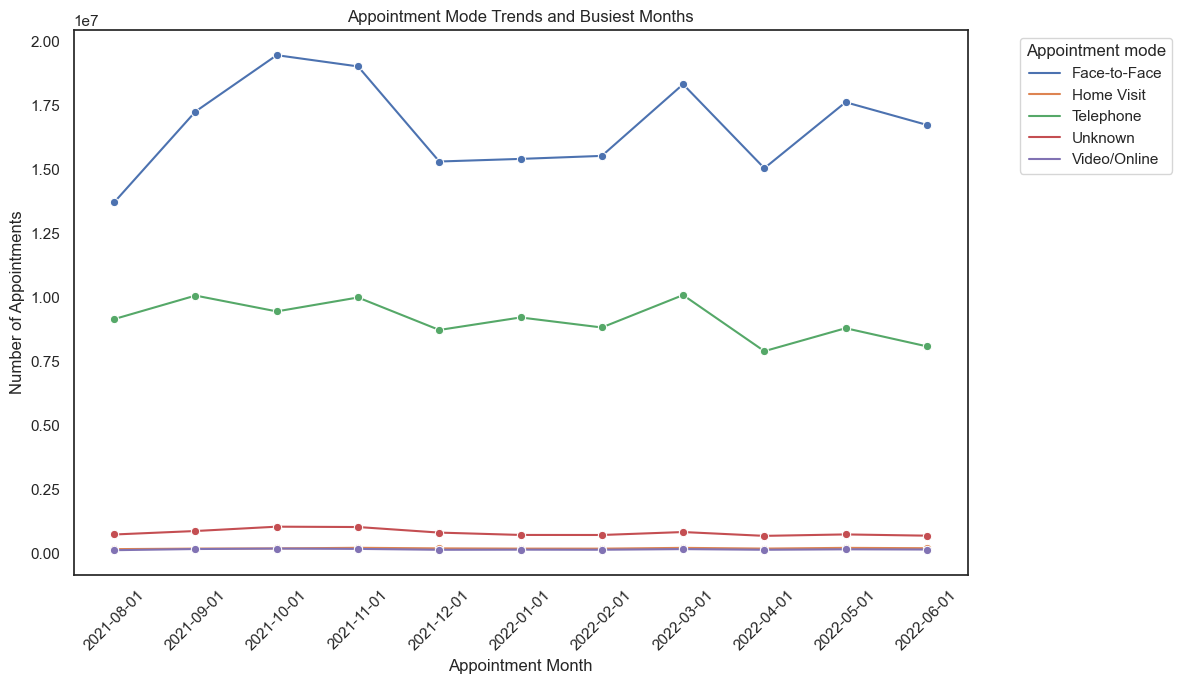

In [177]:
# Create a line plot to answer the question.

# Grouping by appointment_month and appointment_mode, summing count_of_appointments
mode_trend = ar_agg.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()

# Convert appointment_month to string for better visualization on x-axis
mode_trend['appointment_month'] = mode_trend['appointment_month'].astype(str)

plt.figure(figsize=(12, 7))
sns.lineplot(data=mode_trend, x='appointment_month', y='count_of_appointments', hue='appointment_mode', marker='o')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding labels and title
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')
plt.title('Appointment Mode Trends and Busiest Months')

# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Appointment mode')

# Display the plot
plt.tight_layout()
plt.show()

**Question 5:** Are there any trends in time between booking and appointment?

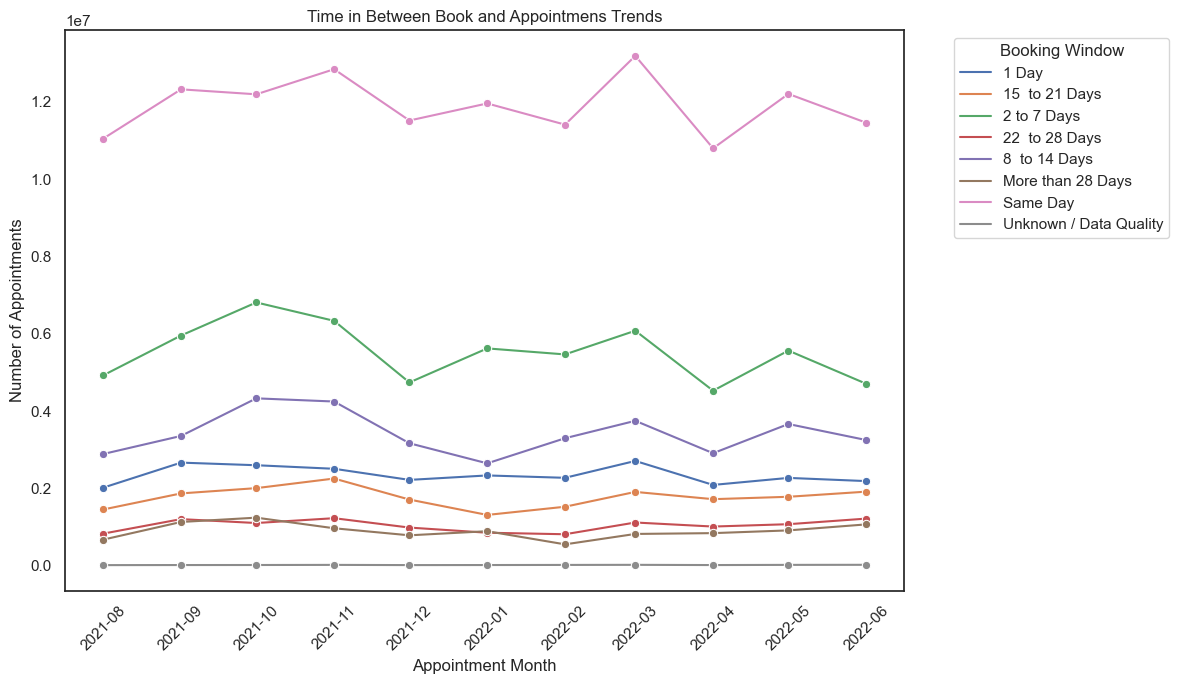

In [179]:
# Create a line plot to answer the question.

# Grouping by appointment_month and time_between_book_and_appointment, summing count_of_appointments
time_in_between_trend = ar_agg.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()

# Convert appointment_month to string for better visualization on x-axis
mode_trend['appointment_month'] = mode_trend['appointment_month'].astype(str)

plt.figure(figsize=(12, 7))
sns.lineplot(data=time_in_between_trend, x='appointment_month', y='count_of_appointments', hue='time_between_book_and_appointment', marker='o')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding labels and title
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')
plt.title('Time in Between Book and Appointmens Trends')

# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Booking Window')

# Display the plot
plt.tight_layout()
plt.show()

**Question 6:** How do the various service settings compare?

In [181]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc = pd.read_excel(r'C:\Users\bocco\OneDrive\Documents\Education\20240708-20250208 - LSE - Data Analytics Career Accelerator'
                 r'\Course 2\Assigment\LSE_DA201_Assignment_files- UPDATED\LSE_DA201_Assignment_files\national_categories.xlsx')

# View the DataFrame.
print(nc.shape)
print('\n')
print(nc.columns)
print('\n')
nc.head()

(817394, 8)


Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')




,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-01,E54000040,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,General Practice,Care Related Encounter,General Consultation Routine,31,2021-08
1,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,Unmapped,Unmapped,Unmapped,1191,2021-08
2,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,Primary Care Network,Care Related Encounter,Unplanned Clinical Activity,3,2021-08
3,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,Primary Care Network,Care Related Encounter,Structured Medication Review,66,2021-08
4,2021-08-02,E54000040,NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,Primary Care Network,Care Related Encounter,Social Prescribing Service,7,2021-08


In [183]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_small = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
nc_small

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843
5,2021-09,Extended Access Provision,187906
6,2021-09,General Practice,25940821
7,2021-09,Other,527174
8,2021-09,Primary Care Network,530485
9,2021-09,Unmapped,1336115


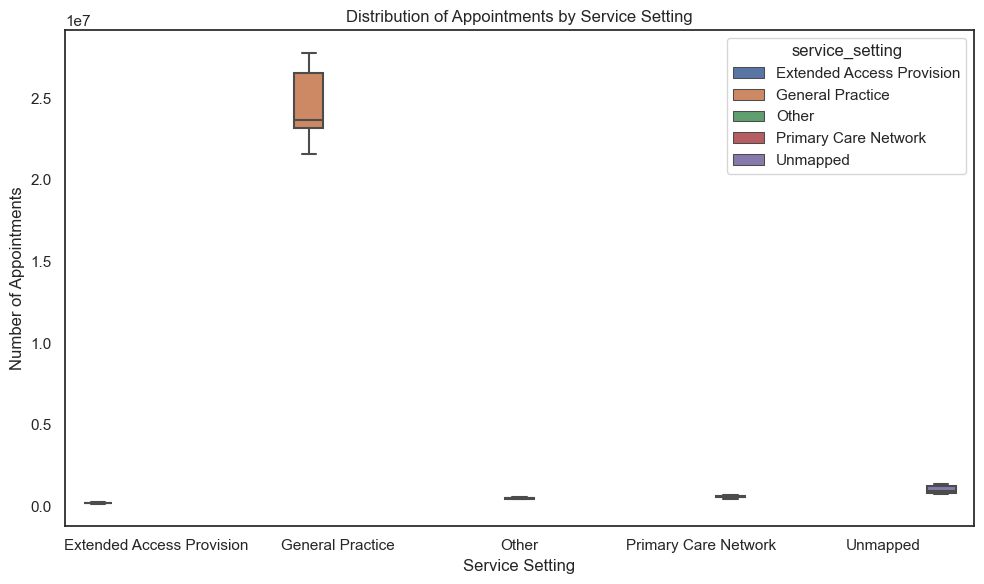

In [185]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
# Convert appointment_month to string for better visualization on x-axis
nc_small['service_setting'] = nc_small['service_setting'].astype(str)

plt.figure(figsize=(10, 6))
sns.boxplot(data=nc_small, x='service_setting', y='count_of_appointments', hue='service_setting')

# Customize the plot
plt.xticks(rotation=0)
plt.xlabel('Service Setting')
plt.ylabel('Number of Appointments')
plt.title('Distribution of Appointments by Service Setting')

# Move legend outside of plot
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')


# Display the plot
plt.tight_layout()
plt.show()

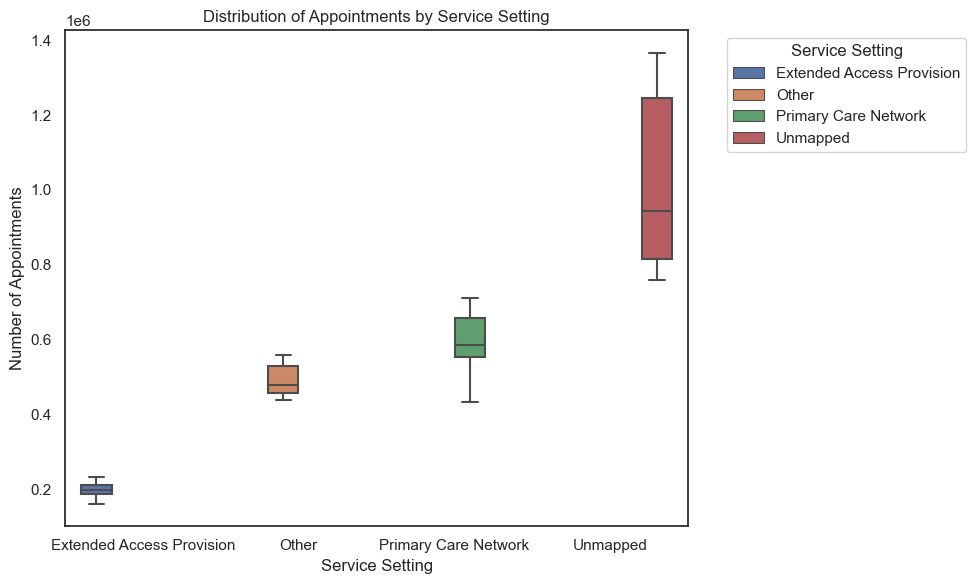

In [187]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.

# Create a new DataFrame excluding General Practice
nc_small_no_gp = nc_small[nc_small['service_setting'] != 'General Practice']

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=nc_small_no_gp, x='service_setting', y='count_of_appointments', hue='service_setting')

# Customize the plot
plt.xticks(rotation=0)
plt.xlabel('Service Setting')
plt.ylabel('Number of Appointments')
plt.title('Distribution of Appointments by Service Setting')

# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Setting')


# Display the plot
plt.tight_layout()
plt.show()

# 

### Provide a summary of your findings and recommendations based on the analysis.

> Double click to insert your summary.

In this document, numbers have the "," as thousands separator, and the "." as decimal separator.  

The files were loaded, and then data check was performed, to be sure nor missing nor null values were present.    
Then, the data analysis continued by exploring the data set.  
The total number of locations in the "national categories" dataset is 106.  
The five locations with the highest number of appointments are 
 - NHS North West London ICB - W2U3Z, with 12,142,390 appointments;  
 - NHS North East London ICB - A3A8R, with 9,588,891 appointments;  
 - NHS Kent and Medway ICB - 91Q, with 9,286,167 appointments;  
 - NHS Hampshire and Isle Of Wight ICB - D9Y0V, with 8,288,102 appointments;  
 - NHS South East London ICB - 72Q, with 7,850,170 appointmens.

There are 18 national categories. In the following table, each different national category is shown, together with the number of times it is present in the file.

| National Category                                                   | Number |
|---------------------------------------------------------------------|--------|
| Inconsistent Mapping                                                | 89,494  |
| General Consultation Routine                                        | 89,329  |
| General Consultation Acute                                          | 84,874  |
| Planned Clinics                                                     | 76,429  |
| Clinical Triage                                                     | 74,539  |
| Planned Clinical Procedure                                          | 59,631  |
| Structured Medication Review                                        | 44,467  |
| Service provided by organisation external to the practice           | 43,095  |
| Home Visit                                                          | 41850  |
| Unplanned Clinical Activity                                         | 40415  |
| Patient contact during Care Home Round                              | 28795  |
| Unmapped                                                            | 27419  |
| Care Home Visit                                                     | 26644  |
| Social Prescribing Service                                          | 26492  |
| Care Home Needs Assessment & Personalised Care and Support Planning | 23505  |
| Non-contractual chargeable work                                     | 20896  |
| Walk-in                                                             | 14179  |
| Group Consultation and Group Education                              | 5341   |   

Here, the number of service settings is given.  

Type of service setting     |    Count|
|---------------------------|---------|
|General Practice           |  359,274|
|Primary Care Network       |  183,790|
|Other                      |  138,789|
|Extended Access Provision  |  108,122|
|Unmapped                   |  27,419|

The General Practice (GP) has the highest number of service settings, followed by the Primary Care Network.

Regarding the context type, there are 700,481 care related encounter which fit determined categories, 89,494 care related encounter which do not fit such categories, and 27,419 unmapped.
Regarding the appointment status, 232,137 appointments were attended, 163,360 were not attended (DNA) and 201,304 were unknown status.

The minimum appointment date in the "actual duration" dateframe is 2021-12-01.     
The maximum appointment date in the "actual duration" dateframe is 2022-06-30.  
The minimum appointment date in the "national categories" dateframe is 2021-08-01.   
The maximum appointment date in the "national categories" dateframe is 2022-06-30.

The most popular service setting from 1 January to 1 June 2022 is 'General Practice' with 4,804,239 appointments.
The month with the highest number of appointmens was Novebmer 2021, with 30,405,070 appointmens. In the following table, the complete list of months and respective number of appointments.


|Month     | Number of appointments|
|----------|-----------------------|
|2021-11   | 30,405,070  |
|2021-10   | 30,303,834  |
|2022-03   | 29,595,038  |
|2021-09   | 28,522,501  |
|2022-05   | 27,495,508  |
|2022-06   | 25,828,078  |
|2022-01   | 25,635,474  | 
|2022-02   | 25,355,260  |
|2021-12   | 25,140,776  |
|2022-04   | 23,913,060  |
|2021-08   | 23,852,171  |

Hereby, the total number of records per month.  
| Month | Number of records |
|-------|-------------------|
|2022-03  |  82,822|
|2021-11  |  77,652|
|2022-05  |  77,425|
|2021-09  |  74,922|
|2022-06  |  74,168|
|2021-10  |  74,078|
|2021-12  |  72,651|
|2022-01  |  71,896|
|2022-02  |  71,769|
|2022-04  |  70,012|
|2021-08  |  69,999|

Looking at the "Sum of Appointments by Service Setting per Month" plot, the GP has the highest number of appointments. The number of appointments increases from August 2021 to November 2021, then decreases in December 2021 and it remains stable until February 2022. Then, the number of appointments oscillates from March to June 2026.

A similar trend can be depicted from the care related encounter, in the "Sum of Appointments by Context Type per Month" plot. Here, the care related enncounter is the type of context with the highest number of appointments.

The "Sum of Appointments by National Category per Month" shows that the general consultation routine is the most popular appointment type, followed by the general consultation type, and by the clinical triage.

Looking at the number of appointments for service setting per season, does not give much info. However, if the data are plotted per day, it is easily depicted how the number of appointments is decreasing from Monday to Friday. In Autumn, there is a curious oscillating trend of number of appointments on Saturdays. In the other seasons, the number of appointments approaches zero on Saturdays and Sundays.

Regarding Twitter, there are 50 hashtags counted more than ten times. The first one is #healthcare, followed by #health, #ai, #medicine, and #job.

There are multiple ways NHS could use Twitter. For example
- Use it to share the news about NHS, such as new policies, how laws are followed, new research achievements, and so on,
- Customer care, by answering tweets and comments,
- Sending tweets on a particular topic, collect the replies, and analyze them.

Besides that, NHS could collect tweets based on keywords and hashtags, chosen by the topic NHS wants to investigate. Then statistical analysis could be performed, in order to sugest where to invest funds and what to improve.

Looking at the count of appointments per month and comparing it with the percentage of capacity utilization per month, it can be seen that they follow a similar trend. In Autumn, the capacity percentage raises almost to 85%. The GP is the professional with the highest number of appointments, passed by other practice, in October 2021. The vast majority of the appointment was attended, with a face-to-face appointment mode being the most popular, followed by the telephone one.

Appointments at the same day of booking are the most popular, followed by appointment within 2 to 7 days after booking. Then 8 to 14 days, followed by appointments 1 day after booking. This can be a positive result, due to the efficiency of NHS, but it could also hide a way of working under "emergency", like last-come-first-served approach. This should be investigated more deeply.

The distribution of appointments by service settings shows that the appointments to the GP are positively skewed. The second service setting is the unmapped, also positively skewed. Here, there is room for improvement. NHS should take action in order to better map the appointments, in order to recognize more deeply which service setting could be improved.
